## Making a General PINN MODEL for IHT

Our Aim

- Make a NN architecture class with variable number of layers and number of neurons per layer

- Make a custom loss function that has option of dropping loss term due to governing equation (as we won't be predicting thermal diffusivity for case 2 and 3 )



### Importing Modules

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

import os

In [ ]:

class PINN_Architecture(nn.Module) :

    def __init__(self, num_hidden_layers, neurons_per_layer,SiLU_Activation=False) :
        super(PINN_Architecture, self).__init__()

        self.input_layer = nn.Linear(in_features=2, out_features=neurons_per_layer)


        self.hidden_layers = nn.ModuleList()
        for _ in range(num_hidden_layers):
            self.hidden_layers.append(nn.Linear(neurons_per_layer, neurons_per_layer))

        self.output_layer = nn.Linear(in_features=neurons_per_layer, out_features=1)

        if SiLU_Activation :
            self.activation = nn.SiLU()
        else :
            self.activation = nn.Tanh()


    def forward(self,x_and_t) :

        out = self.activation(self.input_layer(x_and_t))

        for layer in self.hidden_layers:
            out = self.activation(layer(out))

        T_pred = self.output_layer(out)

        return T_pred

In [ ]:
mse_loss = nn.MSELoss()

def custom_loss(model, x_data, t_data, T_data, alpha, q, k, lambda_data, lambda_pde, lambda_bc, include_gov_eq_loss:bool) :

    # Data loss
    inputs_data = torch.cat([x_data, t_data], dim=1)
    T_pred = model(inputs_data)
    loss_data = torch.mean((T_pred - T_data)**2)


    # Gov eq loss
    if include_gov_eq_loss :

        dT_dt = torch.autograd.grad(T_pred, t_data, torch.ones_like(T_pred), create_graph=True)[0]
        dT_dx = torch.autograd.grad(T_pred, x_data, torch.ones_like(T_pred), create_graph=True)[0]
        d2T_dx2 = torch.autograd.grad(dT_dx, x_data, torch.ones_like(dT_dx), create_graph=True)[0]

        loss_pde = torch.mean((dT_dt - alpha * d2T_dx2)**2)


    # Bc loss
    x_bc = torch.zeros_like(t_data, requires_grad=True)
    inputs_bc = torch.cat([x_bc, t_data], dim=1)
    T_pred_bc = model(inputs_bc)

    dT_dx_bc = torch.autograd.grad(T_pred_bc, x_bc, torch.ones_like(T_pred_bc), create_graph=True)[0]

    loss_bc = torch.mean((dT_dx_bc + (q / k))**2)


    # Total loss

    if include_gov_eq_loss :
        total_loss = lambda_data*loss_data + lambda_pde*loss_pde + lambda_bc*loss_bc
    else :
        total_loss = lambda_data*loss_data + lambda_bc*loss_bc

    if include_gov_eq_loss :
        return total_loss, loss_data, loss_pde, loss_bc
    else :
      return total_loss, loss_data, loss_bc

### Choosing Device

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print("Device :",device)

Device : cuda


Defining Training Function

In [ ]:
def train(model,opt_nn,opt_q,opt_alpha,sched_nn,sched_q,sched_alpha,const_x,const_t,const_T,alpha,q,k,lambda_data=10,lambda_pde=10,lambda_bc=1,start_epoch=0,epochs=15_000,include_gov_eq_loss=True,tmax=3600,Tmax=1,save_freq=None,penalty_scheduler=None,change_args=()) :

# scaler = torch.amp.GradScaler('cuda')

  for epoch in range(start_epoch,epochs):

    opt_nn.zero_grad()
    opt_q.zero_grad()
    if include_gov_eq_loss :
      opt_alpha.zero_grad()

    # with torch.amp.autocast('cuda') :
    if include_gov_eq_loss :
      total_loss, loss_data, loss_pde, loss_bc = custom_loss(
            model,
            const_x, const_t, const_T,
            # x_col, t_col,
            alpha, q, k,
            lambda_data,lambda_pde,lambda_bc,
            include_gov_eq_loss
      )
    else :

       if penalty_scheduler is not None :
          lambda_data_modified,lambda_bc_modified = penalty_scheduler(epoch, lambda_data, lambda_bc, *change_args)
       else :
          lambda_data_modified = lambda_data
          lambda_bc_modified = lambda_bc

       total_loss, loss_data, loss_bc = custom_loss(
            model,
            const_x, const_t, const_T,
            # x_col, t_col,
            alpha, q, k,
            lambda_data_modified,lambda_pde,lambda_bc_modified,
            include_gov_eq_loss
      )

    total_loss.backward()


    opt_nn.step()
    opt_q.step()
    if include_gov_eq_loss :
      opt_alpha.step()

    sched_nn.step()
    sched_q.step()
    if include_gov_eq_loss :
      sched_alpha.step()

    # scaler.update()
    if include_gov_eq_loss :
        if ((epoch+1) % 1000 == 0) or (epoch == start_epoch) :
            print(f'Epoch : {epoch+1}',f'Total loss : {total_loss.item()}',f'q : {q.item()*Tmax}', f'alpha : {alpha.item()/tmax}', f"\ndata loss : {loss_data.item()}", f"pde loss : {loss_pde.item()}", f"bc loss : {loss_bc.item()}\n", sep=' | ')
    else :
        if ((epoch+1) % 1000 == 0) or (epoch == start_epoch) :
            print(f'Epoch : {epoch+1}',f'Total loss : {total_loss.item()}',f'q : {q.item()*Tmax}', f"\ndata loss : {loss_data.item()}",  f"bc loss : {loss_bc.item()}\n", sep=' | ')


    if save_freq is not None :
      if ((epoch + 1) % save_freq == 0):
              current_dir = os.getcwd()
              filename = os.path.join(current_dir, f"model_checkpoint.pth")

              torch.save({
                  'epoch': epoch,
                  'model_state_dict': model.state_dict(),
                  'optimizer_state_dict': optimizer.state_dict(),
                  'loss': total_loss.item(),
                  'alpha_tensor': alpha.data,
                  'q_tensor': q.data
              }, filename)

              print(f"--> Saved checkpoint to {filename} at epoch : {epoch}")
    else :
      pass

Defining lbfgs optimization function

In [ ]:


def lbfgs_optimization(model,const_x,const_t,const_T,alpha,q,k,lambda_data=10,lambda_pde=10,lambda_bc=1,lr=0.01,max_iter=1_000,max_eval=1_000,include_gov_eq_loss=True,tmax=3600) :

  global all_trainable_params

  optimizer_lbfgs = optim.LBFGS(
      all_trainable_params,
      lr,
      max_iter,
      max_eval,
      # tolerance_grad=1e-10,
      # tolerance_change=1e-12,
      #history_size=50,
      # line_search_fn="strong_wolfe"
  )


  def closure():
      global lbfgs_iter

      optimizer_lbfgs.zero_grad()

      if include_gov_eq_loss :
        total_loss, loss_data, loss_pde, loss_bc = custom_loss(
            model,
            const_x, const_t, const_T,
            #x_col, t_col,
            alpha, q, k,
            lambda_data,lambda_pde,lambda_bc,
            include_gov_eq_loss
        )
      else :
        total_loss, loss_data, loss_bc = custom_loss(
            model,
            const_x, const_t, const_T,
            #x_col, t_col,
            alpha, q, k,
            lambda_data,lambda_pde,lambda_bc,
            include_gov_eq_loss
        )


      total_loss.backward()


      if include_gov_eq_loss :
        if ((lbfgs_iter+1) % 1000 == 0) or (lbfgs_iter == 0):
            print(f'L-BFGS Iteration : {lbfgs_iter+1}',f'Total loss : {total_loss.item()}',f'q : {q.item()}', f'alpha : {alpha.item()/tmax}', f"\ndata loss : {loss_data.item()}", f"pde loss : {loss_pde.item()}", f"bc loss : {loss_bc.item()}\n", sep=' | ')
      else :
          if ((lbfgs_iter+1) % 1000 == 0) or (lbfgs_iter == 0):
            print(f'L-BFGS Iteration : {lbfgs_iter+1}',f'Total loss : {total_loss.item()}',f'q : {q.item()}', f"\ndata loss : {loss_data.item()}", f"bc loss : {loss_bc.item()}\n", sep=' | ')

      lbfgs_iter += 1

      return total_loss



  optimizer_lbfgs.step(closure)

<br><br><br><br><br><br><br><br><br><br><br><br><br>

## CASE 1 : Constant Heat Flux



### Preparing the Data

In [ ]:
file = np.load("const_pinn_data.npz")
# file = np.load("../input/datasets/maazk10/const-pinn-data/const_pinn_data.npz")
const_pinn_data = file['saved_data']
file.close()

In [ ]:
print(const_pinn_data.shape)

(2200,)


In [ ]:
print(const_pinn_data)

[(0.58 ,  570., 0.48191505) (0.36 , 1965., 9.25429917)
 (0.995, 2955., 5.75281457) ... (0.745, 2355., 4.74543597)
 (0.52 , 2790., 9.48069095) (0.51 ,  315., 0.15802518)]


In [ ]:
tmax = 3600
Tmax = 1 # 28.78

In [ ]:
const_pinn_data_tensor = torch.tensor(const_pinn_data.tolist(),dtype=torch.float64)

print(const_pinn_data_tensor.shape)

const_x = const_pinn_data_tensor[:,0:1]
const_t = const_pinn_data_tensor[:,1:2]/tmax
const_T = const_pinn_data_tensor[:,2:3]/Tmax

const_x = const_x.requires_grad_(True).to(device)
const_t = const_t.requires_grad_(True).to(device)
const_T = const_T.requires_grad_(True).to(device)

print(const_x)
print(const_t)
print(const_T)

torch.Size([2200, 3])
tensor([[0.5800],
        [0.3600],
        [0.9950],
        ...,
        [0.7450],
        [0.5200],
        [0.5100]], device='cuda:0', dtype=torch.float64,
       grad_fn=<ToCopyBackward0>)
tensor([[0.1583],
        [0.5458],
        [0.8208],
        ...,
        [0.6542],
        [0.7750],
        [0.0875]], device='cuda:0', dtype=torch.float64,
       grad_fn=<ToCopyBackward0>)
tensor([[0.4819],
        [9.2543],
        [5.7528],
        ...,
        [4.7454],
        [9.4807],
        [0.1580]], device='cuda:0', dtype=torch.float64,
       grad_fn=<ToCopyBackward0>)


Defining collocated points : these are points where pde loss (loss due to governing equation) is being computed

In [ ]:
# x_col = const_x
# t_col = const_t

### Sub-case 1.1 : Training without Noisy data

### Initializing the model

In [ ]:
model = PINN_Architecture(num_hidden_layers=8, neurons_per_layer=20,SiLU_Activation=False).to(device)
model = model.to(torch.float64)

#### Defining learning rates for Model Parameters

In [ ]:
lr_nn = 0.001
lr_alpha = 0.001
lr_q = 5.0

Defining Model Parameters  & Optimizer

In [ ]:
alpha = nn.Parameter(torch.tensor([0.001 * tmax], device=device))
q = nn.Parameter(torch.tensor([0.0 / Tmax], device=device))

In [ ]:
opt_nn = torch.optim.Adam(model.parameters(), lr=lr_nn)
opt_alpha = torch.optim.Adam([alpha], lr=lr_alpha)
opt_q = torch.optim.Adam([q], lr=lr_q)

sched_nn = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=1.0)
sched_alpha = torch.optim.lr_scheduler.ConstantLR(opt_alpha, factor=1.0)
sched_q = torch.optim.lr_scheduler.LinearLR(opt_q, start_factor=0.02, end_factor=1.0, total_iters=2000)

In [ ]:
k=237

#### Training

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [ ]:

train(model,
      opt_nn,opt_q,opt_alpha,sched_nn,sched_q,sched_alpha,
      const_x,const_t,const_T,
      alpha,q,k,
      lambda_data=20,lambda_pde=10,lambda_bc=1,
      start_epoch=0, epochs=60_000,include_gov_eq_loss=True,tmax=tmax,Tmax=Tmax,save_freq=None)

Epoch : 1 | Total loss : 2058.074320176635 | q : -0.09991954267024994 | alpha : 0.0009997224145465427 | 
data loss : 102.90371513944335 | pde loss : 1.520804007497806e-06 | bc loss : 2.179727816109185e-06

Epoch : 1000 | Total loss : 872.3630394836695 | q : -0.010225803591310978 | alpha : 0.0009827533033159043 | 
data loss : 43.61815194978024 | pde loss : 4.8776197434959676e-08 | bc loss : 3.0261263922782026e-10

Epoch : 2000 | Total loss : 872.3439419460964 | q : 0.0008237125002779067 | alpha : 0.0009826869434780546 | 
data loss : 43.61719664630404 | pde loss : 9.019468436546104e-07 | bc loss : 5.472378966672362e-10

Epoch : 3000 | Total loss : 86.52207664842088 | q : 3847.974609375 | alpha : 0.000901501973470052 | 
data loss : 3.8221800528032195 | pde loss : 0.9625625028634283 | bc loss : 0.45285056372221494

Epoch : 4000 | Total loss : 58.32980814001229 | q : 4226.56982421875 | alpha : 0.0008529865079455906 | 
data loss : 2.625701015477327 | pde loss : 0.15061884682705015 | bc loss 

2. L-BFGS optimization

In [ ]:
# all_trainable_params = list(model.parameters()) + [alpha, q]
# lbfgs_iter = 0

# lbfgs_optimization(model,
#                    const_x,const_t,const_T,
#                    # x_col,t_col,
#                    alpha,q,k,
#                    lambda_data=10,lambda_pde=10,lambda_bc=1,
#                    lr=0.001,max_iter=5_000,max_eval=5_000,
#                    include_gov_eq_loss=True,tmax=3600)

L-BFGS Iteration : 1 | Total loss : 0.02471122331917286 | q : 9975.0576171875 | alpha : 9.902862211068472e-05 | 
data loss : 0.0012633894803002477 | pde loss : 0.0010142597602680326 | bc loss : 0.0019347307970747352



#### Predictions

We first prepare data for prediction

In [ ]:
const_x_np = np.linspace(0,1,201,endpoint=True)

const_t_np = np.linspace(0,3600,241,endpoint=True)/tmax


const_x_pred = torch.from_numpy(const_x_np).double()
const_t_pred = torch.from_numpy(const_t_np).double()

# test_input = torch.cartesian_prod(const_t_pred,const_x_pred)[:,[1,0]] when on cpu
test_input = torch.cartesian_prod(const_t_pred,const_x_pred)[:,[1,0]].to(device)

In [ ]:



model.eval()
with torch.no_grad() :
   const_T_pred = model(test_input)


# const_T_pred = const_T_pred.detach().numpy().reshape((241,201) # when on cpu
const_T_pred = const_T_pred.cpu().detach().numpy().reshape((241,201))


q_const = q.item()*Tmax
alpha_const = alpha.item()/tmax

print('Discovered Values (without noise): ')
print('q :', q_const)
print('alpha :', alpha_const)

Discovered Values (without noise): 
q : 9999.58984375
alpha : 9.862602584891849e-05


In [ ]:
const_T_pred *= Tmax
print(const_T_pred)

[[ 2.28210381  2.07951335  1.88541053 ... -0.16950507 -0.17177688
  -0.17395739]
 [ 2.76618763  2.5608071   2.36322846 ... -0.1645936  -0.16684958
  -0.1690142 ]
 [ 3.21159206  3.00441341  2.80444396 ... -0.15951143 -0.1617446
  -0.16388655]
 ...
 [28.66524063 28.45497433 28.24579209 ...  8.09634407  8.09452674
   8.09366731]
 [28.73077951 28.52054413 28.31138846 ...  8.15352799  8.15165319
   8.15073563]
 [28.79623305 28.58603041 28.37690283 ...  8.21069233  8.20875804
   8.20778029]]


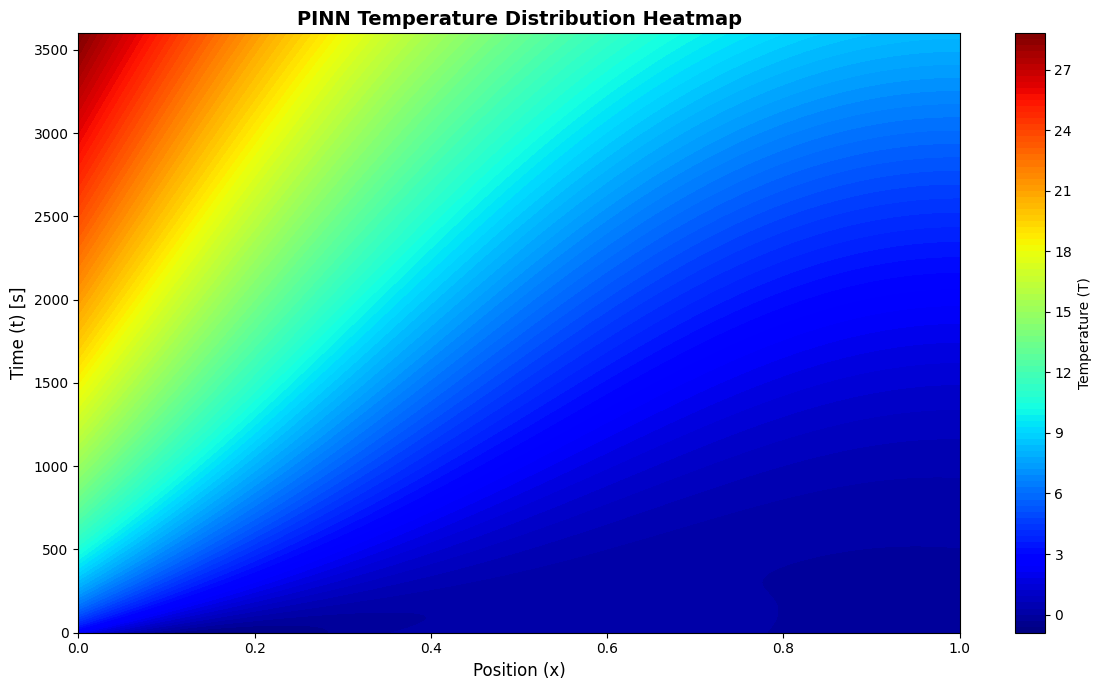

In [ ]:
plt.figure(figsize=(12, 7))
heatmap = plt.contourf(const_x_np, const_t_np*3600, const_T_pred, levels=100, cmap='jet')
plt.colorbar(heatmap, label='Temperature (T)')

plt.xlabel('Position (x)', fontsize=12)
plt.ylabel('Time (t) [s]', fontsize=12)
plt.title('PINN Temperature Distribution Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Evalution

loading gt for constant case

In [ ]:
file = np.load('const_gt.npz')
T_gt_const= file['saved_data']
file.close()

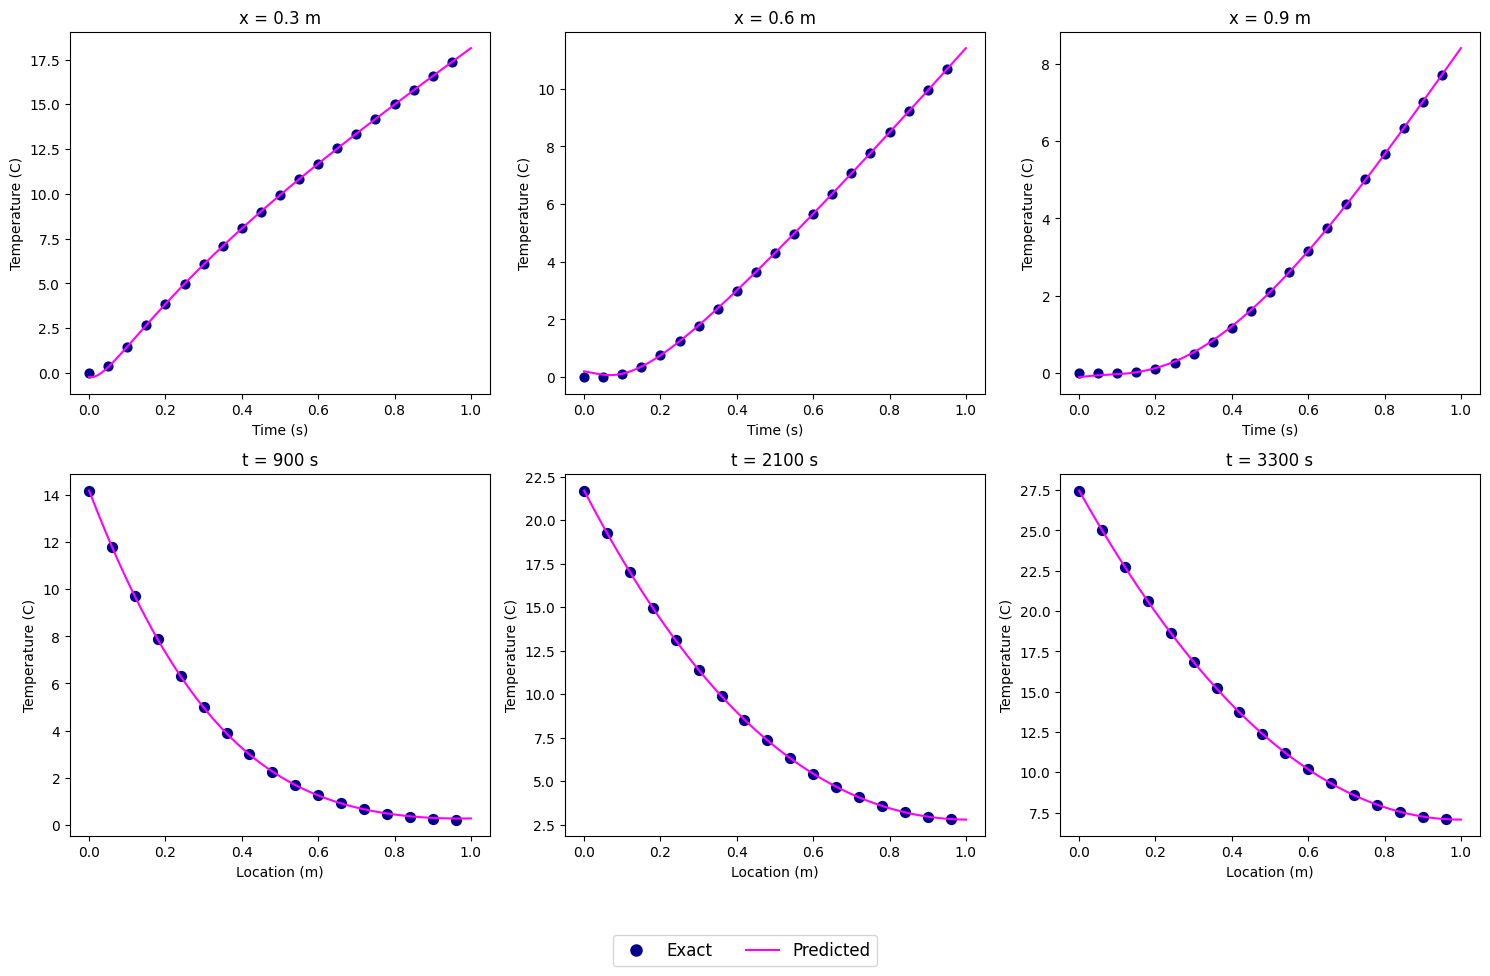

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

axes[0, 0].plot(const_t_np, const_T_pred[:,int(0.3*201)].T, color='magenta')
axes[0, 0].scatter(const_t_np[0:-1:12], T_gt_const[0:-1:12,int(0.3*201)].T,color='darkblue',marker='o',s=40)
axes[0, 0].set_title('x = 0.3 m')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Temperature (C)')



axes[0, 1].plot(const_t_np, const_T_pred[:,int(0.6*201)].T, color='magenta')
axes[0, 1].scatter(const_t_np[0:-1:12], T_gt_const[0:-1:12,int(0.6*201)].T,color='darkblue',marker='o',s=40)
axes[0, 1].set_title('x = 0.6 m')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Temperature (C)')



axes[0, 2].plot(const_t_np, const_T_pred[:,int(0.9*201)].T, color='magenta')
axes[0, 2].scatter(const_t_np[0:-1:12], T_gt_const[0:-1:12,int(0.9*201)].T,color='darkblue',marker='o',s=40)
axes[0, 2].set_title('x = 0.9 m')
axes[0, 2].set_xlabel('Time (s)')
axes[0, 2].set_ylabel('Temperature (C)')



axes[1, 0].plot(const_x_np, const_T_pred[int(900*241/3600)], color='magenta')
axes[1, 0].scatter(const_x_np[0:-1:12], T_gt_const[int(900*241/3600),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 0].set_title('t = 900 s')
axes[1, 0].set_xlabel('Location (m)')
axes[1, 0].set_ylabel('Temperature (C)')



axes[1, 1].plot(const_x_np, const_T_pred[int(2100*241/3600)], color='magenta')
axes[1, 1].scatter(const_x_np[0:-1:12], T_gt_const[int(2100*241/3600),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 1].set_title('t = 2100 s')
axes[1, 1].set_xlabel('Location (m)')
axes[1, 1].set_ylabel('Temperature (C)')



axes[1, 2].plot(const_x_np, const_T_pred[int(3300*241/3600)], color='magenta')
axes[1, 2].scatter(const_x_np[0:-1:12], T_gt_const[int(3300*241/3600),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 2].set_title('t = 3300 s')
axes[1, 2].set_xlabel('Location (m)')
axes[1, 2].set_ylabel('Temperature (C)')


line_symbol = mlines.Line2D([], [], color='magenta', label='Predicted')

scatter_symbol = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='Exact')

fig.legend(handles=[scatter_symbol,line_symbol],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=2,
           fontsize=12)


plt.tight_layout(rect=[0,0.1,1,1])

plt.show()

<br><br><br><br><br><br><br><br><br><br><br><br><br>

### Sub-case 1.2 : Training with Noisy data

Preparing Data

In [ ]:
file = np.load('const_pinn_data_noisy.npz')

const_pinn_data_noisy = file['saved_data']
file.close()


const_pinn_data_noisy_tensor = torch.tensor(const_pinn_data_noisy.tolist(),dtype=torch.float32)

print(const_pinn_data_tensor.shape)

const_x = const_pinn_data_noisy_tensor[:,0:1]
const_t = const_pinn_data_noisy_tensor[:,1:2]/tmax
const_T_noisy = const_pinn_data_noisy_tensor[:,2:3]

const_x = const_x.requires_grad_(True).to(device)
const_t = const_t.requires_grad_(True).to(device)
const_T_noisy = const_T_noisy.requires_grad_(True).to(device)

print(const_x)
print(const_t)
print(const_T_noisy)

# x_col = const_x
# t_col = const_t

torch.Size([2200, 3])
tensor([[0.5800],
        [0.3600],
        [0.9950],
        ...,
        [0.7450],
        [0.5200],
        [0.5100]], device='cuda:0', grad_fn=<ToCopyBackward0>)
tensor([[0.1583],
        [0.5458],
        [0.8208],
        ...,
        [0.6542],
        [0.7750],
        [0.0875]], device='cuda:0', grad_fn=<ToCopyBackward0>)
tensor([[ 0.3820],
        [ 9.1064],
        [ 5.7659],
        ...,
        [ 4.9938],
        [ 8.8583],
        [-0.1051]], device='cuda:0', grad_fn=<ToCopyBackward0>)


#### Training

In [ ]:
model = PINN_Architecture(num_hidden_layers=8, neurons_per_layer=20).to(device)
model = model.to(torch.float32)

lr_nn = 0.001
lr_alpha = 0.001
lr_q = 5.0



alpha = nn.Parameter(torch.tensor([0.001*3600],device=device, requires_grad=True))
q = nn.Parameter(torch.tensor([0.0],device=device, requires_grad=True))

opt_nn = torch.optim.Adam(model.parameters(), lr=lr_nn)
opt_alpha = torch.optim.Adam([alpha], lr=lr_alpha)
opt_q = torch.optim.Adam([q], lr=lr_q)

sched_nn = torch.optim.lr_scheduler.ExponentialLR(opt_nn, gamma=1.0)
sched_alpha = torch.optim.lr_scheduler.ExponentialLR(opt_alpha, gamma=1.0)
sched_q = torch.optim.lr_scheduler.LinearLR(opt_q, start_factor=0.02, end_factor=1.0, total_iters=2000)

k = 237



In [ ]:
train(model,
      opt_nn,opt_q,opt_alpha,sched_nn,sched_q,sched_alpha,
      const_x,const_t,const_T_noisy,
      alpha,q,k,
      lambda_data=20,lambda_pde=10,lambda_bc=1,
      start_epoch=0, epochs=60_000,include_gov_eq_loss=True,tmax=tmax,Tmax=Tmax,save_freq=None)




Epoch : 1 | Total loss : 2051.94580078125 | q : 0.09984981268644333 | alpha : 0.0009997224145465427 | 
data loss : 102.5972900390625 | pde loss : 1.4761393458684324e-06 | bc loss : 6.227626272448106e-07

Epoch : 1000 | Total loss : 877.5123291015625 | q : -0.0020693382248282433 | alpha : 0.0009816345241334702 | 
data loss : 43.87561798095703 | pde loss : 1.731696563922469e-08 | bc loss : 1.4531707000914329e-12

Epoch : 2000 | Total loss : 877.0847778320312 | q : 1.7948424816131592 | alpha : 0.0009161105420854356 | 
data loss : 43.85369873046875 | pde loss : 0.0010798900621011853 | bc loss : 3.791927611018764e-06

Epoch : 3000 | Total loss : 79.84310150146484 | q : 3916.413818359375 | alpha : 0.0008208282788594564 | 
data loss : 3.790071964263916 | pde loss : 0.3182384669780731 | bc loss : 0.85927414894104

Epoch : 4000 | Total loss : 59.0706901550293 | q : 4283.2041015625 | alpha : 0.0007717790206273397 | 
data loss : 2.590947389602661 | pde loss : 0.10413359105587006 | bc loss : 6.210

#### Predictions

In [ ]:
const_x_np = np.linspace(0,1,201,endpoint=True)
const_t_np = np.linspace(0,3600,241,endpoint=True)/tmax

const_x_pred = torch.from_numpy(const_x_np).float()
const_t_pred = torch.from_numpy(const_t_np).float()


test_input = torch.cartesian_prod(const_t_pred,const_x_pred)[:,[1,0]].to(device)

const_T_pred_noisy = model(test_input)

const_T_pred_noisy = const_T_pred_noisy.cpu().detach().numpy().reshape((241,201))


q_const_noisy = q.item()
alpha_const_noisy = alpha.item()/tmax

print('Discovered Values (with noise): ')
print('q :', q_const_noisy)
print('alpha :', alpha_const_noisy)

Discovered Values (with noise): 
q : 10039.3564453125
alpha : 9.78657603263855e-05


#### Evalution

In [ ]:
file = np.load('const_gt.npz')
T_gt_const= file['saved_data']
file.close()

In [ ]:
file = np.load('const_gt_noisy.npz')
T_gt_const_noisy= file['saved_data']
file.close()

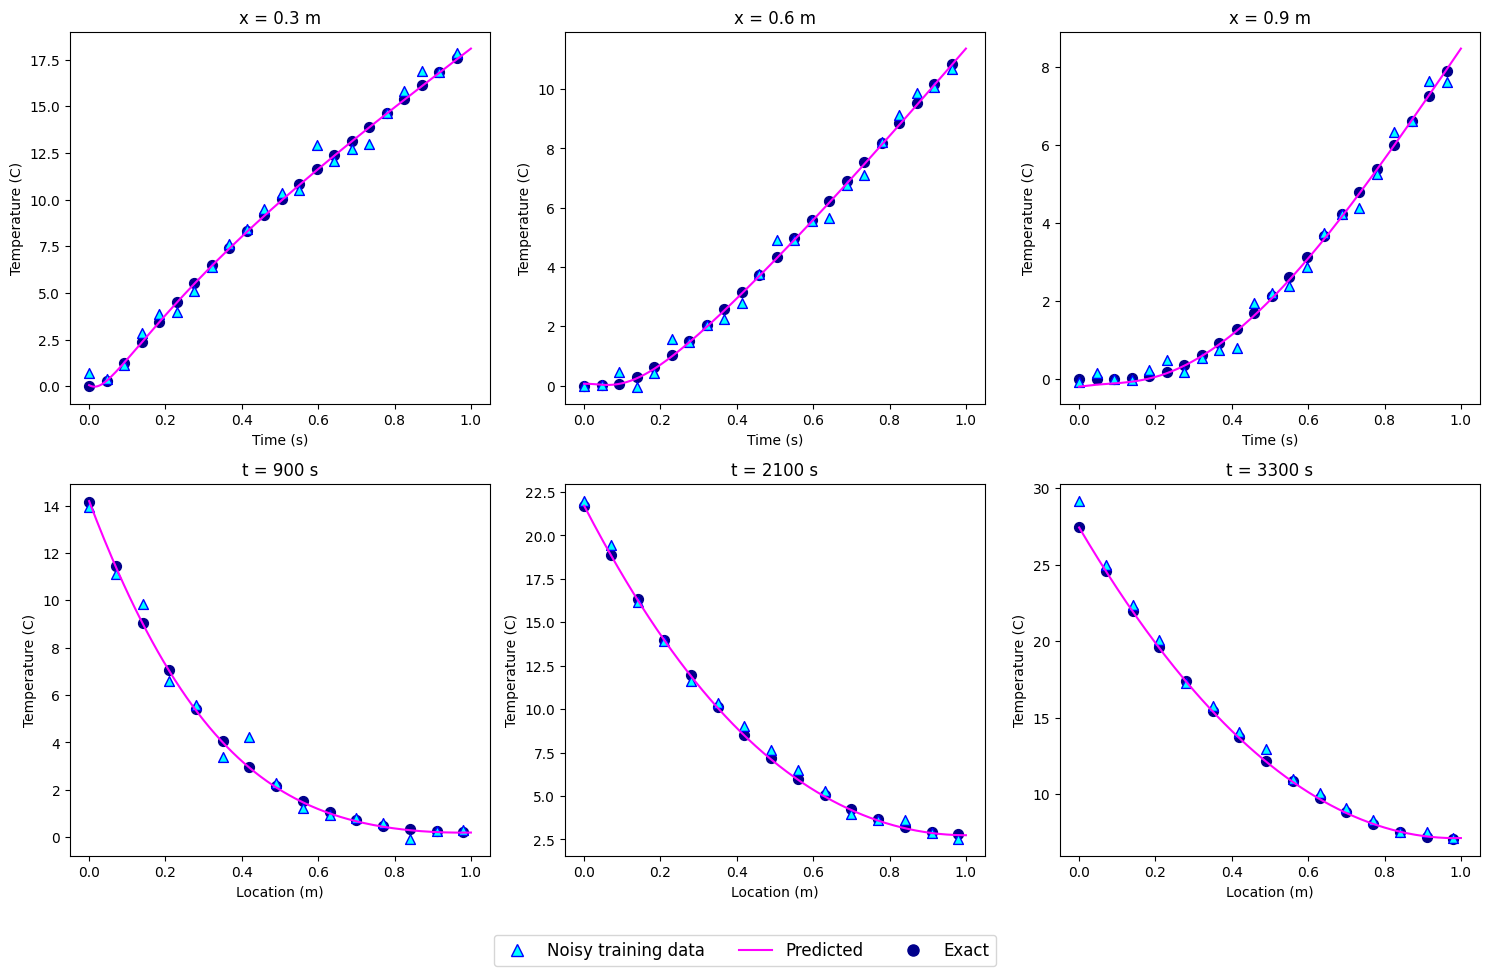

In [ ]:
figs, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

n = int(241/(21))
axes[0, 0].plot(const_t_np, const_T_pred_noisy[:,int(0.3*201)].T, color='magenta')
axes[0, 0].scatter(const_t_np[0:-1:n], T_gt_const[0:-1:n,int(0.3*201)].T,color='darkblue',marker='o',s=50)
axes[0, 0].scatter(const_t_np[0:-1:n], T_gt_const_noisy[0:-1:n,int(0.3*201)].T,marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[0, 0].set_title('x = 0.3 m')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Temperature (C)')



axes[0, 1].plot(const_t_np, const_T_pred_noisy[:,int(0.6*201)].T, color='magenta')
axes[0, 1].scatter(const_t_np[0:-1:n], T_gt_const[0:-1:n,int(0.6*201)].T,color='darkblue',marker='o',s=50)
axes[0, 1].scatter(const_t_np[0:-1:n], T_gt_const_noisy[0:-1:n,int(0.6*201)].T,marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[0, 1].set_title('x = 0.6 m')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Temperature (C)')



axes[0, 2].plot(const_t_np, const_T_pred_noisy[:,int(0.9*201)].T, color='magenta')
axes[0, 2].scatter(const_t_np[0:-1:n], T_gt_const[0:-1:n,int(0.9*201)].T,color='darkblue',marker='o',s=50)
axes[0, 2].scatter(const_t_np[0:-1:n], T_gt_const_noisy[0:-1:n,int(0.9*201)].T,marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[0, 2].set_title('x = 0.9 m')
axes[0, 2].set_xlabel('Time (s)')
axes[0, 2].set_ylabel('Temperature (C)')


m = int(241/(17))
axes[1, 0].plot(const_x_np, const_T_pred_noisy[int(900*241/3600)], color='magenta')
axes[1, 0].scatter(const_x_np[0:-1:m], T_gt_const[int(900*241/3600),0:-1:m],color='darkblue',marker='o',s=50)
axes[1, 0].scatter(const_x_np[0:-1:m], T_gt_const_noisy[int(900*241/3600),0:-1:m],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[1, 0].set_title('t = 900 s')
axes[1, 0].set_xlabel('Location (m)')
axes[1, 0].set_ylabel('Temperature (C)')



axes[1, 1].plot(const_x_np, const_T_pred_noisy[int(2100*241/3600)], color='magenta')
axes[1, 1].scatter(const_x_np[0:-1:m], T_gt_const[int(2100*241/3600),0:-1:m],color='darkblue',marker='o',s=50)
axes[1, 1].scatter(const_x_np[0:-1:m], T_gt_const_noisy[int(2100*241/3600),0:-1:m],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[1, 1].set_title('t = 2100 s')
axes[1, 1].set_xlabel('Location (m)')
axes[1, 1].set_ylabel('Temperature (C)')



axes[1, 2].plot(const_x_np, const_T_pred_noisy[int(3300*241/3600)], color='magenta')
axes[1, 2].scatter(const_x_np[0:-1:m], T_gt_const[int(3300*241/3600),0:-1:m],color='darkblue',marker='o',s=50)
axes[1, 2].scatter(const_x_np[0:-1:m], T_gt_const_noisy[int(3300*241/3600),0:-1:m],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[1, 2].set_title('t = 3300 s')
axes[1, 2].set_xlabel('Location (m)')
axes[1, 2].set_ylabel('Temperature (C)')


line_symbol = mlines.Line2D([], [], color='magenta', label='Predicted')

circle = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='Exact')
triangle = mlines.Line2D([], [], marker='^', linestyle='None',
                               markersize=8, markerfacecolor='cyan', markeredgecolor='blue', linewidth=3, label='Noisy training data')

figs.legend(handles=[triangle,line_symbol,circle],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=3,
           fontsize=12)


plt.tight_layout(rect=[0,0.08,1,1])

plt.show()

### Generating Error heatmap for both the cases

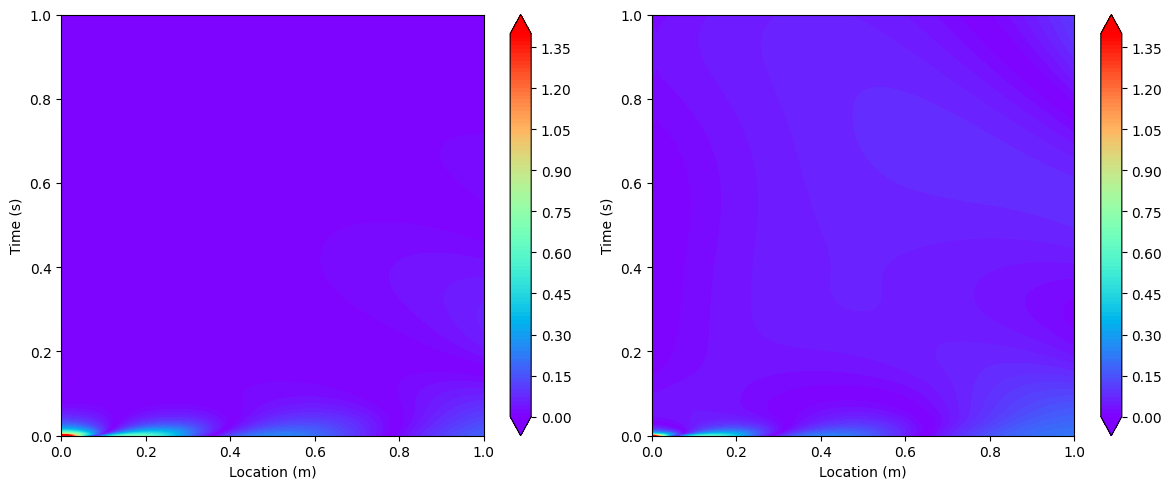

In [ ]:
figs,axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

levels = np.linspace(0, 1.4, 100)

heatmap = axes[0].contourf(
    const_x_np,const_t_np,np.abs(const_T_pred-T_gt_const),
    levels=levels,
    cmap='rainbow',
    extend='both'
)
cbar_ticks = np.arange(0.00, 1.36, 0.15)
cbar = figs.colorbar(heatmap, ax=axes[0], ticks=cbar_ticks)
axes[0].set_xlabel('Location (m)')
axes[0].set_ylabel('Time (s)')




heatmap = axes[1].contourf(
    const_x_np,const_t_np,np.abs(const_T_pred_noisy-T_gt_const),
    levels=levels,
    cmap='rainbow',
    extend='both'
)
cbar_ticks = np.arange(0.00, 1.36, 0.15)
cbar = figs.colorbar(heatmap, ax=axes[1], ticks=cbar_ticks)
axes[1].set_xlabel('Location (m)')
axes[1].set_ylabel('Time (s)')
# axes[1].set_title('Error in Constant Case')

plt.tight_layout()
plt.show()

<br><br><br><br><br><br><br><br><br><br><br><br><br>

## CASE 2 : Linear Heat Flux



### Subcase 2.1 : 0% Noisy Dataset

### Preparing Data

In [ ]:
torch.set_default_dtype(torch.float64)

In [ ]:
tmax=2000
Tmax=35.241

In [ ]:
file = np.load('linear_pinn_data.npz')
linear_pinn_data = file['saved_data']
file.close()

In [ ]:
print(linear_pinn_data.shape)

(1809,)


In [ ]:
linear_pinn_data_tensor = torch.tensor(linear_pinn_data.tolist(),dtype=torch.float64)

print(linear_pinn_data_tensor.shape)

linear_x = linear_pinn_data_tensor[:,0:1]
linear_t = linear_pinn_data_tensor[:,1:2]/tmax
linear_T = linear_pinn_data_tensor[:,2:3]/Tmax

linear_x = linear_x.requires_grad_(True).to(device)
linear_t = linear_t.requires_grad_(True).to(device)
linear_T = linear_T.requires_grad_(True).to(device)

print(linear_x)
print(linear_t)
print(linear_T)


torch.Size([1809, 3])
tensor([[0.0000],
        [0.0050],
        [0.0100],
        ...,
        [0.9900],
        [0.9950],
        [1.0000]], requires_grad=True)
tensor([[5.0000e-04],
        [5.0000e-04],
        [5.0000e-04],
        ...,
        [1.0000e+00],
        [1.0000e+00],
        [1.0000e+00]], requires_grad=True)
tensor([[0.0129],
        [0.0083],
        [0.0047],
        ...,
        [0.0902],
        [0.0901],
        [0.0901]], requires_grad=True)


In [ ]:
# x_col = linear_x
# t_col = linear_t

In [ ]:
temporal_points_linear = np.concatenate((np.array([0]),np.linspace(250,2000,8,endpoint=True)))

print(temporal_points_linear)

[   0.  250.  500.  750. 1000. 1250. 1500. 1750. 2000.]


In [ ]:
import gc
gc.collect()


948

### Method 1

In [ ]:
def penalty_scheduler(epoch, lambda_data, lambda_bc, change_epoch) :
  if epoch < change_epoch :
    return lambda_data, lambda_bc*0
  else :
    return lambda_data, lambda_bc

In [ ]:
models = []
q_vals = []

for i,p in zip(range(len(temporal_points_linear)),temporal_points_linear):

    print(f"Training for temporal point t = {p} s ...\n")

    model = PINN_Architecture(num_hidden_layers=3, neurons_per_layer=30,SiLU_Activation=True).to(device)
    model = model.to(torch.float64)

    lr_nn = 0.001
    # lr_alpha = 0.001
    lr_q = 6.5 # 6.5 goated



    # alpha = nn.Parameter(torch.tensor([0.001*3600],device=device, requires_grad=True))
    q = nn.Parameter(torch.tensor([0.0],device=device, requires_grad=True))

    opt_nn = torch.optim.Adam(model.parameters(), lr=lr_nn)
    # opt_alpha = torch.optim.Adam([alpha], lr=lr_alpha)
    opt_q = torch.optim.Adam([q], lr=lr_q)

    sched_nn_1 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=1.0)
    sched_nn_2 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=0.0,total_iters=10_000)
    sched_nn_3 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=0.05,total_iters=40_000)

    sched_nn = torch.optim.lr_scheduler.SequentialLR(opt_nn,
                                                     schedulers = [sched_nn_1,
                                                                   sched_nn_2,
                                                                   sched_nn_3
                                                                   ],
                                                     milestones=[20_000,30_000]
    )

    # sched_alpha = torch.optim.lr_scheduler.ExponentialLR(opt_alpha, gamma=1.0)

    #sched_q = torch.optim.lr_scheduler.LinearLR(opt_q, start_factor=0.02, end_factor=1.0, total_iters=2000)
    sched_q_1 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=1)
    sched_q_2 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=0.8,total_iters=30_000)
    sched_q = torch.optim.lr_scheduler.SequentialLR(opt_q,
                                                    schedulers=[sched_q_1,
                                                                sched_q_2
                                                                ],
                                                    milestones=[40_000]
    )

    all_trainable_params = list(model.parameters()) + [q]

    k = 237

    print(f"Confirming that t = {linear_t[i*201,0]*tmax} s")

    l_data = 1000
    l_bc = 1
    start=0


    train(model,
        opt_nn,opt_q,None,sched_nn,sched_q,None,
        linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T[i*201:i*201+200],
        None,q,k,
        lambda_data=l_data,lambda_pde=0,lambda_bc=l_bc,
        start_epoch=start,epochs=70_000,include_gov_eq_loss=False,tmax=tmax,Tmax=Tmax,save_freq=None,
        penalty_scheduler=penalty_scheduler,change_args=(20_000,))





    # lbfgs_iter = 0
    # lbfgs_optimization(model,
    #                linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T[i*201:i*201+200],x_col[i*201:i*201+200],t_col[i*201:i*201+200],
    #                None,q,k,
    #                lambda_data=10,lambda_pde=0,lambda_bc=1,
    #                lr=0.01,max_iter=1_000,max_eval=1_000,
    #                include_gov_eq_loss=False,tmax=2000)

    models.append(model)
    q_vals.append(q.item())




Training for temporal point t = 0.0 s ...

Confirming that t = 1.0 s
Epoch : 1 | Total loss : 21.019702269283123 | q : 0.0 | 
data loss : 0.02101970226928312 | bc loss : 3.992216385295178e-06

Epoch : 1000 | Total loss : 0.0012177603723395156 | q : 0.0 | 
data loss : 1.2177603723395156e-06 | bc loss : 1.952738534456566e-06

Epoch : 2000 | Total loss : 0.0011704599802900703 | q : 0.0 | 
data loss : 1.1704599802900702e-06 | bc loss : 7.937824658387029e-06

Epoch : 3000 | Total loss : 0.0011456479642307966 | q : 0.0 | 
data loss : 1.1456479642307966e-06 | bc loss : 1.8141880754357767e-05

Epoch : 4000 | Total loss : 0.0011408762595569912 | q : 0.0 | 
data loss : 1.1408762595569912e-06 | bc loss : 2.523734145231028e-05

Epoch : 5000 | Total loss : 0.001138874049773459 | q : 0.0 | 
data loss : 1.138874049773459e-06 | bc loss : 2.7508618059364804e-05

Epoch : 6000 | Total loss : 0.0011353830833630587 | q : 0.0 | 
data loss : 1.1353830833630586e-06 | bc loss : 2.96651756507836e-05

Epoch : 70

### Method 2

In [ ]:
# models = []
# q_vals = []

# for i,p in zip(range(len(temporal_points_linear)),temporal_points_linear):

#     print(f"Training for temporal point t = {p} s ...\n")

#     model = PINN_Architecture(num_hidden_layers=2, neurons_per_layer=20,SiLU_Activation=True).to(device)
#     model = model.to(torch.float64)

#     lr_nn = 0.001
#     # lr_alpha = 0.001
#     lr_q = 6 #



#     # alpha = nn.Parameter(torch.tensor([0.001*3600],device=device, requires_grad=True))
#     q = nn.Parameter(torch.tensor([0.0],device=device, requires_grad=True))

#     opt_nn = torch.optim.Adam(model.parameters(), lr=lr_nn)
#     # opt_alpha = torch.optim.Adam([alpha], lr=lr_alpha)
#     opt_q = torch.optim.Adam([q], lr=lr_q)

#     sched_nn = torch.optim.lr_scheduler.ExponentialLR(opt_nn, gamma=1.0)

#     # sched_alpha = torch.optim.lr_scheduler.ExponentialLR(opt_alpha, gamma=1.0)

#     #sched_q = torch.optim.lr_scheduler.LinearLR(opt_q, start_factor=0.02, end_factor=1.0, total_iters=2000)
#     sched_q_1 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=1.0)
#     #sched_q_2 = torch.optim.lr_scheduler.StepLR(opt_q, step_size=1000, gamma=1.1)
#     #sched_q_3 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=0.5)
#     sched_q = torch.optim.lr_scheduler.SequentialLR(opt_q,
#                                                     schedulers=[sched_q_1,
#                                                                 #sched_q_2,
#                                                                 #sched_q_3
#                                                                 ],
#                                                     milestones=[]
#     )

#     all_trainable_params = list(model.parameters()) + [q]

#     k = 237

#     print(f"Confirming that t = {linear_t[i*201,0]*tmax} s")

#     if p == 0 :
#       l_data = 1_000_000
#       l_bc = 1_000
#       start=59_000
#     else :
#       l_data = 1000
#       l_bc = 1
#       start=0


#     train(model,
#         opt_nn,opt_q,None,sched_nn,sched_q,None,
#         linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T[i*201:i*201+200],
#         None,q,k,
#         lambda_data=l_data,lambda_pde=0,lambda_bc=l_bc,
#         start_epoch=start,epochs=60_000,include_gov_eq_loss=False,tmax=2000,save_freq=None)





#     # lbfgs_iter = 0
#     # lbfgs_optimization(model,
#     #                linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T[i*201:i*201+200],x_col[i*201:i*201+200],t_col[i*201:i*201+200],
#     #                None,q,k,
#     #                lambda_data=10,lambda_pde=0,lambda_bc=1,
#     #                lr=0.01,max_iter=1_000,max_eval=1_000,
#     #                include_gov_eq_loss=False,tmax=2000)

#     models.append(model)
#     q_vals.append(q.item())




In [ ]:
linear_x_np = np.linspace(0,1,201,endpoint=True)

linear_x_pred = torch.from_numpy(linear_x_np).double()


test_inputs = []

for p in temporal_points_linear/tmax :
  linear_t_point = torch.from_numpy(np.array([p])).double()
  test_inputs.append(torch.cartesian_prod(linear_t_point,linear_x_pred)[:,[1,0]])



In [ ]:
linear_T_preds = []

for i in [3,5,7,9] : # 3 5 7 9th element
  linear_T_preds.append(models[i-1](test_inputs[i-1]).detach().numpy())


linear_T_preds = np.array(linear_T_preds).reshape(4,201)*Tmax

In [ ]:
file = np.load('linear_gt.npz')
T_gt_linear = file['saved_data']
file.close()

In [ ]:
print(T_gt_linear.shape)

(2001, 201)


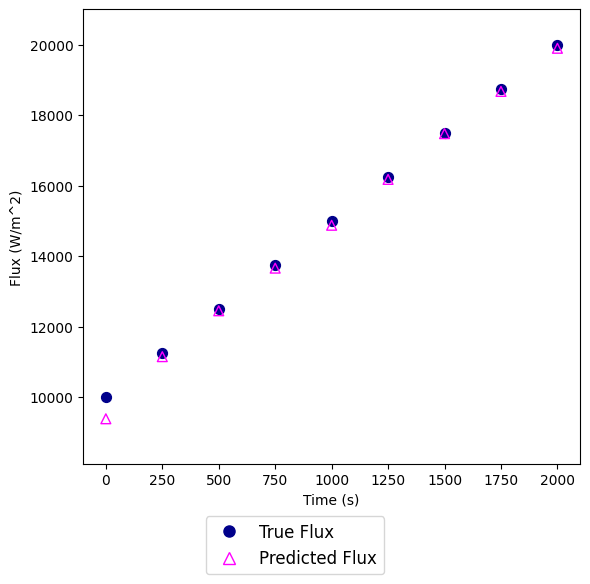

In [ ]:
fig,ax = plt.subplots(figsize=(6,6))
ax.set_ylim(8_100,21_000)
ax.scatter(temporal_points_linear,10000 + 5 * temporal_points_linear,color='darkblue',marker='o',s=50)
ax.scatter(temporal_points_linear,np.array(q_vals)*Tmax,edgecolor='magenta',facecolor='None',marker='^',s=50)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Flux (W/m^2)')


circle = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='True Flux')

triangle = mlines.Line2D([], [], markeredgecolor='magenta',markerfacecolor='None', marker='^', linestyle='None',
                               markersize=8, label='Predicted Flux')

fig.legend(handles=[circle, triangle],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=1,
           fontsize=12)


plt.tight_layout(rect=[0,0.12,1,1])

plt.show()


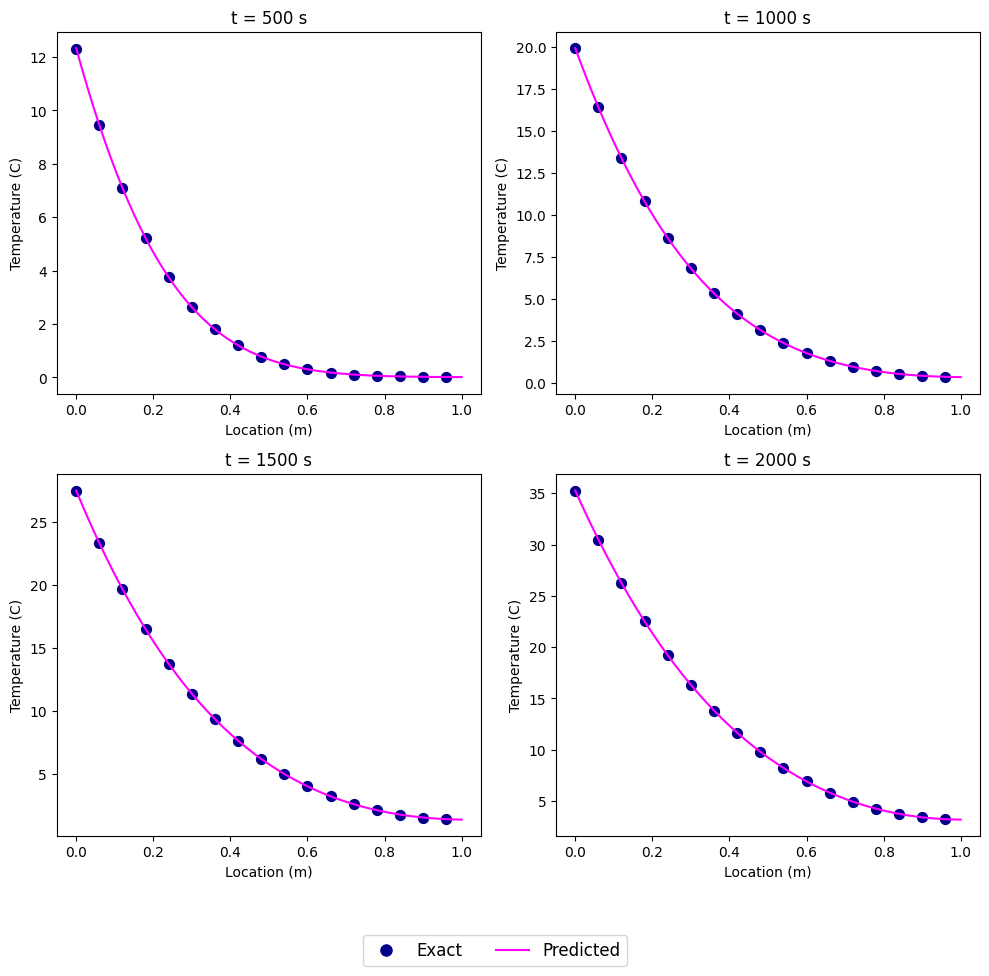

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))


axes[0, 0].plot(linear_x_np, linear_T_preds[0], color='magenta')
axes[0, 0].scatter(linear_x_np[0:-1:12], T_gt_linear[int(500*2000/2000),0:-1:12],color='darkblue',marker='o',s=50)
axes[0, 0].set_title('t = 500 s')
axes[0, 0].set_xlabel('Location (m)')
axes[0, 0].set_ylabel('Temperature (C)')


axes[0, 1].plot(linear_x_np, linear_T_preds[1], color='magenta')
axes[0, 1].scatter(linear_x_np[0:-1:12], T_gt_linear[int(1000*2000/2000),0:-1:12],color='darkblue',marker='o',s=50)
axes[0, 1].set_title('t = 1000 s')
axes[0, 1].set_xlabel('Location (m)')
axes[0, 1].set_ylabel('Temperature (C)')


axes[1, 0].plot(linear_x_np, linear_T_preds[2], color='magenta')
axes[1, 0].scatter(linear_x_np[0:-1:12], T_gt_linear[int(1500*2000/2000),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 0].set_title('t = 1500 s')
axes[1, 0].set_xlabel('Location (m)')
axes[1, 0].set_ylabel('Temperature (C)')



axes[1, 1].plot(linear_x_np, linear_T_preds[3], color='magenta')
axes[1, 1].scatter(linear_x_np[0:-1:12], T_gt_linear[int(2000*2000/2000),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 1].set_title('t = 2000 s')
axes[1, 1].set_xlabel('Location (m)')
axes[1, 1].set_ylabel('Temperature (C)')




line_symbol = mlines.Line2D([], [], color='magenta', label='Predicted')

scatter_symbol = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='Exact')

fig.legend(handles=[scatter_symbol,line_symbol],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=2,
           fontsize=12)


plt.tight_layout(rect=[0,0.1,1,1])

plt.show()

<br><br><br><br><br><br><br><br><br><br><br><br><br>

### Subcase 2.2 : 10% Noisy Dataset

In [ ]:
tmax=2000
Tmax = 35.241

In [ ]:
file = np.load('linear_pinn_data_noisy.npz')
linear_pinn_data_noisy = file['saved_data']
file.close()

In [ ]:
linear_pinn_data_noisy_tensor = torch.tensor(linear_pinn_data_noisy.tolist(),dtype=torch.float64)

print(linear_pinn_data_noisy_tensor.shape)

linear_x = linear_pinn_data_noisy_tensor[:,0:1]
linear_t = linear_pinn_data_noisy_tensor[:,1:2]/tmax
linear_T_noisy = linear_pinn_data_noisy_tensor[:,2:3]/Tmax

linear_x = linear_x.requires_grad_(True).to(device)
linear_t = linear_t.requires_grad_(True).to(device)
linear_T_noisy = linear_T_noisy.requires_grad_(True).to(device)

print(linear_x)
print(linear_t)
print(linear_T_noisy)


torch.Size([1809, 3])
tensor([[0.0000],
        [0.0050],
        [0.0100],
        ...,
        [0.9900],
        [0.9950],
        [1.0000]], requires_grad=True)
tensor([[5.0000e-04],
        [5.0000e-04],
        [5.0000e-04],
        ...,
        [1.0000e+00],
        [1.0000e+00],
        [1.0000e+00]], requires_grad=True)
tensor([[0.0492],
        [0.0107],
        [0.0211],
        ...,
        [0.0927],
        [0.0888],
        [0.0888]], requires_grad=True)


In [ ]:
temporal_points_linear = np.concatenate((np.array([1]),np.linspace(250,2000,8,endpoint=True)))

print(temporal_points_linear)

[1.00e+00 2.50e+02 5.00e+02 7.50e+02 1.00e+03 1.25e+03 1.50e+03 1.75e+03
 2.00e+03]


In [ ]:
import gc
gc.collect()

37592

Method

In [ ]:
def penalty_scheduler(epoch, lambda_data, lambda_bc, change_epoch) :
  if epoch < change_epoch :
    return lambda_data, lambda_bc*0
  else :
    return lambda_data, lambda_bc

In [ ]:
models_noisy = []
q_vals_noisy = []

for i,p in zip(range(len(temporal_points_linear)),temporal_points_linear):

    print(f"Training for temporal point t = {p} s ...\n")

    model = PINN_Architecture(num_hidden_layers=3, neurons_per_layer=30,SiLU_Activation=True).to(device)
    model = model.to(torch.float64)

    lr_nn = 0.001
    # lr_alpha = 0.001
    lr_q = 1 # 6.5 goated



    # alpha = nn.Parameter(torch.tensor([0.001*3600],device=device, requires_grad=True))
    q = nn.Parameter(torch.tensor([0.0],device=device, requires_grad=True))

    opt_nn = torch.optim.Adam(model.parameters(), lr=lr_nn)
    # opt_alpha = torch.optim.Adam([alpha], lr=lr_alpha)
    opt_q = torch.optim.Adam([q], lr=lr_q)

    sched_nn_1 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=1.0)
    sched_nn_2 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=0.0,total_iters=10_000)
    sched_nn_3 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=0.05,total_iters=40_000)

    sched_nn = torch.optim.lr_scheduler.SequentialLR(opt_nn,
                                                     schedulers = [sched_nn_1,
                                                                   sched_nn_2,
                                                                   sched_nn_3
                                                                   ],
                                                     milestones=[20_000,30_000]
    )

    # sched_alpha = torch.optim.lr_scheduler.ExponentialLR(opt_alpha, gamma=1.0)

    #sched_q = torch.optim.lr_scheduler.LinearLR(opt_q, start_factor=0.02, end_factor=1.0, total_iters=2000)
    sched_q_1 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=1)
    sched_q_2 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=0.8,total_iters=30_000)
    sched_q = torch.optim.lr_scheduler.SequentialLR(opt_q,
                                                    schedulers=[sched_q_1,
                                                                sched_q_2
                                                                ],
                                                    milestones=[40_000]
    )

    all_trainable_params = list(model.parameters()) + [q]

    k = 237

    print(f"Confirming that t = {linear_t[i*201,0]*tmax} s")

    l_data = 1000
    l_bc = 1
    start=0


    train(model,
        opt_nn,opt_q,None,sched_nn,sched_q,None,
        linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T_noisy[i*201:i*201+200],
        None,q,k,
        lambda_data=l_data,lambda_pde=0,lambda_bc=l_bc,
        start_epoch=start,epochs=70_000,include_gov_eq_loss=False,tmax=tmax,Tmax=Tmax,save_freq=None,
        penalty_scheduler=penalty_scheduler,change_args=(20_000,))





    # lbfgs_iter = 0
    # lbfgs_optimization(model,
    #                linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T[i*201:i*201+200],x_col[i*201:i*201+200],t_col[i*201:i*201+200],
    #                None,q,k,
    #                lambda_data=10,lambda_pde=0,lambda_bc=1,
    #                lr=0.01,max_iter=1_000,max_eval=1_000,
    #                include_gov_eq_loss=False,tmax=2000)

    models_noisy.append(model)
    q_vals_noisy.append(q.item())




Training for temporal point t = 1.0 s ...

Confirming that t = 1.0 s
Epoch : 1 | Total loss : 18.051102970744452 | q : 0.0 | 
data loss : 0.018051102970744453 | bc loss : 4.94325904666844e-07

Epoch : 1000 | Total loss : 0.17699414649301698 | q : 0.0 | 
data loss : 0.00017699414649301697 | bc loss : 1.5865829645890653e-06

Epoch : 2000 | Total loss : 0.17674471635514263 | q : 0.0 | 
data loss : 0.00017674471635514263 | bc loss : 1.9118078851684607e-05

Epoch : 3000 | Total loss : 0.17657022176773646 | q : 0.0 | 
data loss : 0.00017657022176773647 | bc loss : 8.606951858798727e-05

Epoch : 4000 | Total loss : 0.17656690381674936 | q : 0.0 | 
data loss : 0.00017656690381674935 | bc loss : 9.313167481758527e-05

Epoch : 5000 | Total loss : 0.1765637839986559 | q : 0.0 | 
data loss : 0.00017656378399865592 | bc loss : 9.002597162345179e-05

Epoch : 6000 | Total loss : 0.17655880910099106 | q : 0.0 | 
data loss : 0.00017655880910099107 | bc loss : 8.490206283614663e-05

Epoch : 7000 | Total

In [ ]:
# models_noisy = []
# q_vals_noisy = []

# for i,p in zip(range(len(temporal_points_linear)),temporal_points_linear):

#     print(f"Training for temporal point t = {p} s ...\n")

#     model = PINN_Architecture(num_hidden_layers=2, neurons_per_layer=20,SiLU_Activation=True).to(device)
#     model = model.to(torch.float64)

#     lr_nn = 0.001
#     # lr_alpha = 0.001
#     lr_q = 5 #



#     # alpha = nn.Parameter(torch.tensor([0.001*3600],device=device, requires_grad=True))
#     q = nn.Parameter(torch.tensor([0.0],device=device, requires_grad=True))

#     opt_nn = torch.optim.Adam(model.parameters(), lr=lr_nn)
#     # opt_alpha = torch.optim.Adam([alpha], lr=lr_alpha)
#     opt_q = torch.optim.Adam([q], lr=lr_q)

#     sched_nn = torch.optim.lr_scheduler.ExponentialLR(opt_nn, gamma=1.0)

#     # sched_alpha = torch.optim.lr_scheduler.ExponentialLR(opt_alpha, gamma=1.0)

#     #sched_q = torch.optim.lr_scheduler.LinearLR(opt_q, start_factor=0.02, end_factor=1.0, total_iters=2000)
#     sched_q_1 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=1.0)
#     #sched_q_2 = torch.optim.lr_scheduler.StepLR(opt_q, step_size=1000, gamma=1.1)
#     #sched_q_3 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=0.5)
#     sched_q = torch.optim.lr_scheduler.SequentialLR(opt_q,
#                                                     schedulers=[sched_q_1,
#                                                                 #sched_q_2,
#                                                                 #sched_q_3
#                                                                 ],
#                                                     milestones=[]
#     )

#     all_trainable_params = list(model.parameters()) + [q]

#     k = 237

#     print(f"Confirming that t = {linear_t[i*201,0]*tmax} s")

#     if p == 0 :
#       l_data = 1_000_000
#       l_bc = 1_000
#       start=59_000
#     else :
#       l_data = 1000
#       l_bc = 1
#       start=0


#     train(model,
#         opt_nn,opt_q,None,sched_nn,sched_q,None,
#         linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T_noisy[i*201:i*201+200],
#         None,q,k,
#         lambda_data=l_data,lambda_pde=0,lambda_bc=l_bc,
#         start_epoch=start,epochs=60_000,include_gov_eq_loss=False,tmax=2000,save_freq=None)





#     # lbfgs_iter = 0
#     # lbfgs_optimization(model,
#     #                linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T[i*201:i*201+200],x_col[i*201:i*201+200],t_col[i*201:i*201+200],
#     #                None,q,k,
#     #                lambda_data=10,lambda_pde=0,lambda_bc=1,
#     #                lr=0.01,max_iter=1_000,max_eval=1_000,
#     #                include_gov_eq_loss=False,tmax=2000)

#     models_noisy.append(model)
#     q_vals_noisy.append(q.item())




Training for temporal point t = 0.0 s ...

Confirming that t = 0.0 s
Epoch : 59001 | Total loss : 159556.08111408295 | q : 4.999999232559685 | 
data loss : 0.15955602150844286 | bc loss : 5.960564009361567e-05

Epoch : 60000 | Total loss : 128223.97862318374 | q : 43.95544586714251 | 
data loss : 0.12822397862316218 | bc loss : 2.1548520387550956e-11

Training for temporal point t = 250.0 s ...

Confirming that t = 250.0 s
Epoch : 1 | Total loss : 5373.3919360940545 | q : -4.993685875399334 | 
data loss : 5.373391935215735 | bc loss : 8.783201468943471e-07

Epoch : 1000 | Total loss : 247.15118743319763 | q : 5667.253354646358 | 
data loss : 0.2423792391474268 | bc loss : 4.771948285770839

Epoch : 2000 | Total loss : 228.3312970342038 | q : 7059.941726907342 | 
data loss : 0.22813632327433267 | bc loss : 0.19497375987110707

Epoch : 3000 | Total loss : 225.9935886973747 | q : 7796.695021157247 | 
data loss : 0.22594780350872065 | bc loss : 0.04578518865403243

Epoch : 4000 | Total los

KeyboardInterrupt: 

In [ ]:
linear_x_np = np.linspace(0,1,201,endpoint=True)

linear_x_pred = torch.from_numpy(linear_x_np).double()


test_inputs = []

for p in temporal_points_linear/tmax :
  linear_t_point = torch.from_numpy(np.array([p])).double()
  test_inputs.append(torch.cartesian_prod(linear_t_point,linear_x_pred)[:,[1,0]])



In [ ]:
linear_T_preds_noisy = []

for i in [3,5,7,9] : # 3 5 7 9th element
  linear_T_preds_noisy.append(models_noisy[i-1](test_inputs[i-1]).detach().numpy())

linear_T_preds_noisy = np.array(linear_T_preds_noisy).reshape(4,201)*Tmax

In [ ]:
file = np.load('linear_gt.npz')
T_gt_linear = file['saved_data']
file.close()

In [ ]:
file = np.load('linear_gt_noisy.npz')
T_gt_linear_noisy = file['saved_data']
file.close()

Visualizing noise in data

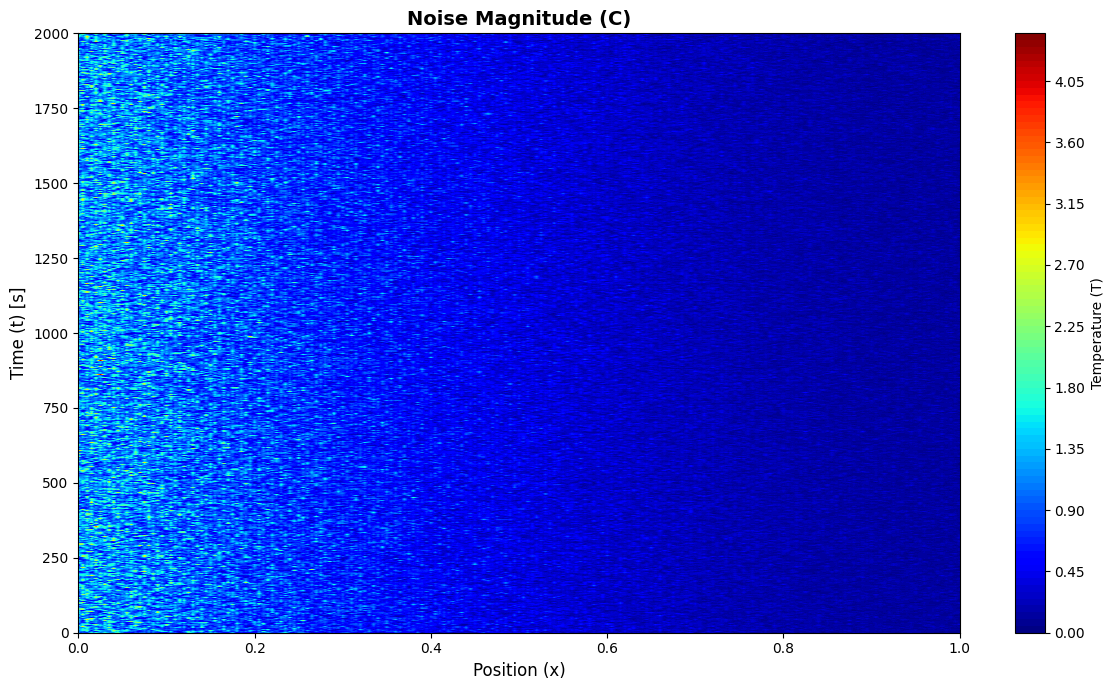

In [ ]:
plt.figure(figsize=(12, 7))
heatmap = plt.contourf(np.linspace(0,1,201,endpoint=True), np.linspace(0,2000,2001,endpoint=True), np.abs(T_gt_linear-T_gt_linear_noisy), levels=100, cmap='jet')
plt.colorbar(heatmap, label='Temperature (T)')

plt.xlabel('Position (x)', fontsize=12)
plt.ylabel('Time (t) [s]', fontsize=12)
plt.title('Noise Magnitude (C)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

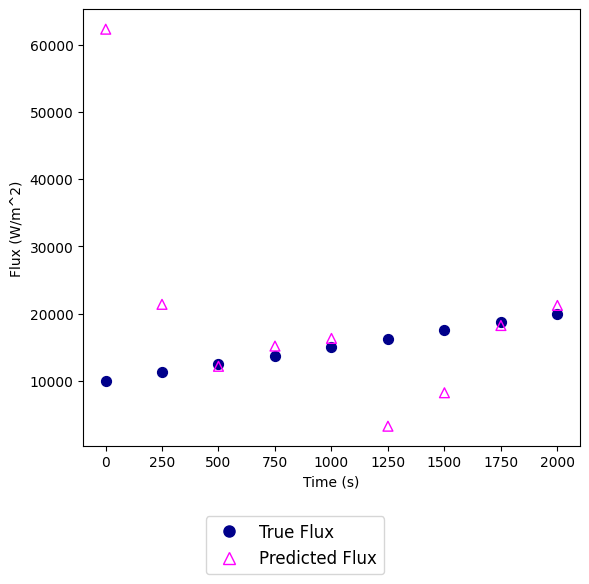

In [ ]:
fig,ax = plt.subplots(figsize=(6,6))

ax.scatter(temporal_points_linear,10000 + 5 * temporal_points_linear,color='darkblue',marker='o',s=50)
ax.scatter(temporal_points_linear,np.array(q_vals_noisy)*Tmax,facecolor='None',edgecolor='magenta',marker='^',s=50)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Flux (W/m^2)')


circle = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='True Flux')

triangle = mlines.Line2D([], [], markeredgecolor='magenta',markerfacecolor='None', marker='^', linestyle='None',
                               markersize=8, label='Predicted Flux')

fig.legend(handles=[circle,triangle],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=1,
           fontsize=12)


plt.tight_layout(rect=[0,0.15,1,1])

plt.show()


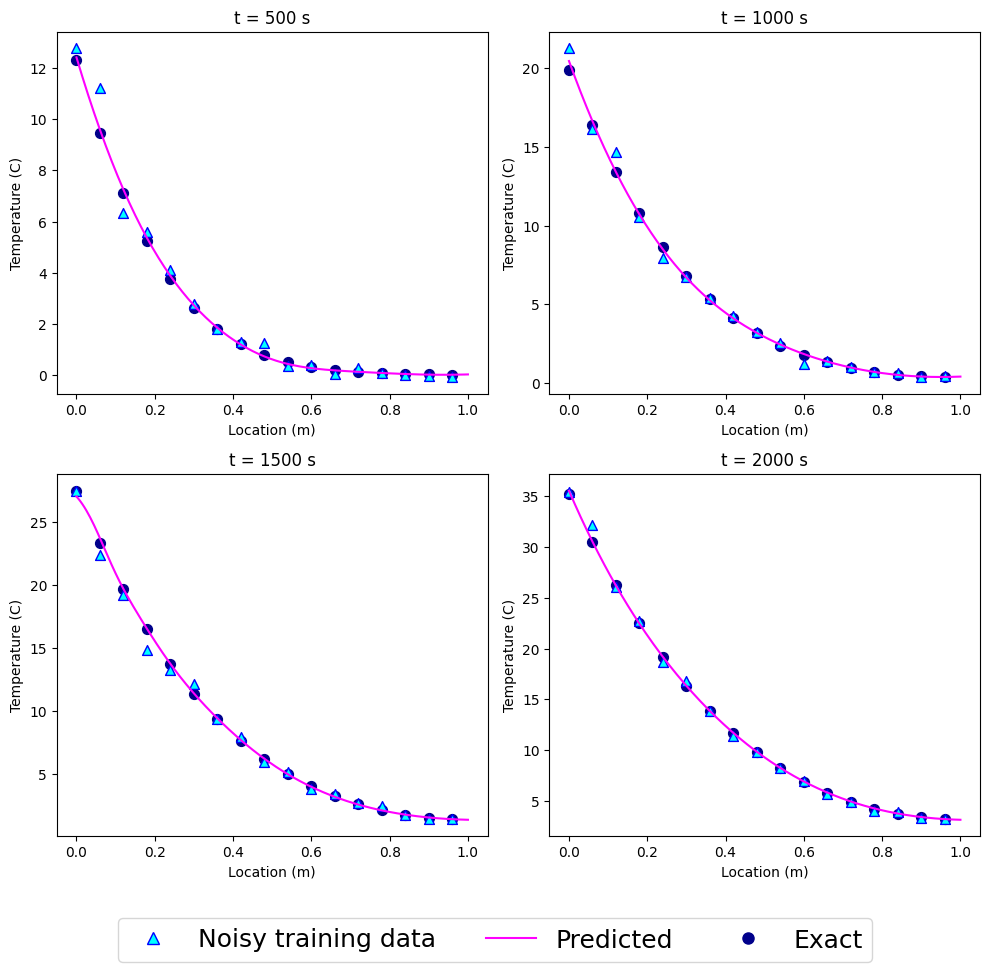

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))



axes[0, 0].plot(linear_x_np, linear_T_preds_noisy[0], color='magenta')
axes[0, 0].scatter(linear_x_np[0:-1:12], T_gt_linear[int(500*2000/2000),0:-1:12],color='darkblue',marker='o',s=50)
axes[0, 0].scatter(linear_x_np[0:-1:12], T_gt_linear_noisy[int(500*2000/2000),0:-1:12],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[0, 0].set_title('t = 500 s')
axes[0, 0].set_xlabel('Location (m)')
axes[0, 0].set_ylabel('Temperature (C)')


axes[0, 1].plot(linear_x_np, linear_T_preds_noisy[1], color='magenta')
axes[0, 1].scatter(linear_x_np[0:-1:12], T_gt_linear[int(1000*2000/2000),0:-1:12],color='darkblue',marker='o',s=50)
axes[0, 1].scatter(linear_x_np[0:-1:12], T_gt_linear_noisy[int(1000*2000/2000),0:-1:12],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[0, 1].set_title('t = 1000 s')
axes[0, 1].set_xlabel('Location (m)')
axes[0, 1].set_ylabel('Temperature (C)')


axes[1, 0].plot(linear_x_np, linear_T_preds_noisy[2], color='magenta')
axes[1, 0].scatter(linear_x_np[0:-1:12], T_gt_linear[int(1500*2000/2000),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 0].scatter(linear_x_np[0:-1:12], T_gt_linear_noisy[int(1500*2000/2000),0:-1:12],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[1, 0].set_title('t = 1500 s')
axes[1, 0].set_xlabel('Location (m)')
axes[1, 0].set_ylabel('Temperature (C)')



axes[1, 1].plot(linear_x_np, linear_T_preds_noisy[3], color='magenta')
axes[1, 1].scatter(linear_x_np[0:-1:12], T_gt_linear[int(2000*2000/2000),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 1].scatter(linear_x_np[0:-1:12], T_gt_linear_noisy[int(2000*2000/2000),0:-1:12],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[1, 1].set_title('t = 2000 s')
axes[1, 1].set_xlabel('Location (m)')
axes[1, 1].set_ylabel('Temperature (C)')




line_symbol = mlines.Line2D([], [], color='magenta', label='Predicted')

circle = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='Exact')

triangle = mlines.Line2D([], [], marker='^', linestyle='None',
                               markersize=8, markerfacecolor='cyan', markeredgecolor='blue', linewidth=3, label='Noisy training data')

fig.legend(handles=[triangle,line_symbol,circle],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=3,
           fontsize=18)


plt.tight_layout(rect=[0,0.1,1,1])

plt.show()

<br><br><br><br><br><br><br><br><br><br><br><br><br>

## CASE 3 : Sinusoidal Heat Flux

### Subcase 3.1: 0% Noisy Dataset

In [ ]:
tmax=1600
Tmax=25.11

In [ ]:
file = np.load('sinusoidal_pinn_data.npz')
sinusoidal_pinn_data = file['saved_data']
file.close()

In [ ]:
print(sinusoidal_pinn_data.shape)

(1809,)


In [ ]:
sinusoidal_pinn_data_tensor = torch.tensor(sinusoidal_pinn_data.tolist(),dtype=torch.float64)

print(sinusoidal_pinn_data_tensor.shape)

sinusoidal_x = sinusoidal_pinn_data_tensor[:,0:1]
sinusoidal_t = sinusoidal_pinn_data_tensor[:,1:2]/tmax
sinusoidal_T = sinusoidal_pinn_data_tensor[:,2:3]/Tmax

sinusoidal_x = sinusoidal_x.requires_grad_(True).to(device)
sinusoidal_t = sinusoidal_t.requires_grad_(True).to(device)
sinusoidal_T = sinusoidal_T.requires_grad_(True).to(device)

print(sinusoidal_x)
print(sinusoidal_t)
print(sinusoidal_T)


torch.Size([1809, 3])
tensor([[0.0000],
        [0.0050],
        [0.0100],
        ...,
        [0.9900],
        [0.9950],
        [1.0000]], requires_grad=True)
tensor([[6.2500e-04],
        [6.2500e-04],
        [6.2500e-04],
        ...,
        [1.0000e+00],
        [1.0000e+00],
        [1.0000e+00]], requires_grad=True)
tensor([[0.0274],
        [0.0177],
        [0.0101],
        ...,
        [0.1163],
        [0.1162],
        [0.1162]], requires_grad=True)


In [ ]:
# x_col = sinusoidal_x
# t_col = sinusoidal_t

In [ ]:
temporal_points_sinusoidal = np.array([1,160,400,640,800,960,1200,1440,1600]) # should be 900 instead of 960 it seems

print(temporal_points_sinusoidal)

[   1  160  400  640  800  960 1200 1440 1600]


In [ ]:
def penalty_scheduler(epoch, lambda_data, lambda_bc, change_epoch) :
  if epoch < change_epoch :
    return lambda_data, lambda_bc*0
  else :
    return lambda_data, lambda_bc

In [ ]:
models = []
q_vals = []

for i,p in zip(range(len(temporal_points_sinusoidal)),temporal_points_sinusoidal):

    print(f"Training for temporal point t = {p} s ...\n")

    model = PINN_Architecture(num_hidden_layers=3, neurons_per_layer=30,SiLU_Activation=True).to(device)
    model = model.to(torch.float64)

    lr_nn = 0.001
    # lr_alpha = 0.001
    lr_q = 6.5 # 6.5 goated



    # alpha = nn.Parameter(torch.tensor([0.001*3600],device=device, requires_grad=True))
    q = nn.Parameter(torch.tensor([0.0],device=device, requires_grad=True))

    opt_nn = torch.optim.Adam(model.parameters(), lr=lr_nn)
    # opt_alpha = torch.optim.Adam([alpha], lr=lr_alpha)
    opt_q = torch.optim.Adam([q], lr=lr_q)

    sched_nn_1 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=1.0)
    sched_nn_2 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=0.0,total_iters=10_000)
    sched_nn_3 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=0.05,total_iters=60_000)

    sched_nn = torch.optim.lr_scheduler.SequentialLR(opt_nn,
                                                     schedulers = [sched_nn_1,
                                                                   sched_nn_2,
                                                                   sched_nn_3
                                                                   ],
                                                     milestones=[20_000,30_000]
    )

    # sched_alpha = torch.optim.lr_scheduler.ExponentialLR(opt_alpha, gamma=1.0)

    #sched_q = torch.optim.lr_scheduler.LinearLR(opt_q, start_factor=0.02, end_factor=1.0, total_iters=2000)
    sched_q_1 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=1)
    sched_q_2 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=0.8,total_iters=50_000)
    sched_q = torch.optim.lr_scheduler.SequentialLR(opt_q,
                                                    schedulers=[sched_q_1,
                                                                sched_q_2
                                                                ],
                                                    milestones=[40_000]
    )

    all_trainable_params = list(model.parameters()) + [q]

    k = 237

    print(f"Confirming that t = {sinusoidal_t[i*201,0]*tmax} s")

    l_data = 1000
    l_bc = 1
    start=0


    train(model,
        opt_nn,opt_q,None,sched_nn,sched_q,None,
        sinusoidal_x[i*201:i*201+200],sinusoidal_t[i*201:i*201+200],sinusoidal_T[i*201:i*201+200],
        None,q,k,
        lambda_data=l_data,lambda_pde=0,lambda_bc=l_bc,
        start_epoch=start,epochs=90_000,include_gov_eq_loss=False,tmax=tmax,Tmax=Tmax,save_freq=None,
        penalty_scheduler=penalty_scheduler,change_args=(20_000,))





    # lbfgs_iter = 0
    # lbfgs_optimization(model,
    #                linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T[i*201:i*201+200],x_col[i*201:i*201+200],t_col[i*201:i*201+200],
    #                None,q,k,
    #                lambda_data=10,lambda_pde=0,lambda_bc=1,
    #                lr=0.01,max_iter=1_000,max_eval=1_000,
    #                include_gov_eq_loss=False,tmax=2000)

    models.append(model)
    q_vals.append(q.item())




Training for temporal point t = 1.0 s ...

Confirming that t = 1.0 s
Epoch : 1 | Total loss : 0.42921796271876494 | q : 0.0 | 
data loss : 0.00042921796271876497 | bc loss : 1.57025089824713e-06

Epoch : 1000 | Total loss : 0.004972091035714649 | q : 0.0 | 
data loss : 4.9720910357146485e-06 | bc loss : 0.00014803246976623024

Epoch : 2000 | Total loss : 0.004491652974110003 | q : 0.0 | 
data loss : 4.491652974110003e-06 | bc loss : 0.001028199352855489

Epoch : 3000 | Total loss : 0.0017640243478034738 | q : 0.0 | 
data loss : 1.764024347803474e-06 | bc loss : 0.20085446347742672

Epoch : 4000 | Total loss : 0.000576760548017822 | q : 0.0 | 
data loss : 5.767605480178221e-07 | bc loss : 1.2141435662163935

Epoch : 5000 | Total loss : 0.0001383929940284147 | q : 0.0 | 
data loss : 1.383929940284147e-07 | bc loss : 2.886825703942072

Epoch : 6000 | Total loss : 4.985604613916733e-05 | q : 0.0 | 
data loss : 4.985604613916733e-08 | bc loss : 4.215597208792111

Epoch : 7000 | Total loss :

In [ ]:
sinusoidal_x_np = np.linspace(0,1,201,endpoint=True)

sinusoidal_x_pred = torch.from_numpy(sinusoidal_x_np).double()


test_inputs = []

for p in temporal_points_sinusoidal/tmax :
  sinusoidal_t_point = torch.from_numpy(np.array([p])).double()
  test_inputs.append(torch.cartesian_prod(sinusoidal_t_point,sinusoidal_x_pred)[:,[1,0]])



In [ ]:
sinusoidal_T_preds = []

for i in [2,3,5,7] : # 2nd,3td, 5th, 7th element
  sinusoidal_T_preds.append(models[i-1](test_inputs[i-1]).detach().numpy())


sinusoidal_T_preds = np.array(sinusoidal_T_preds).reshape(4,201)*Tmax

In [ ]:
file = np.load('sinusoidal_gt.npz')
T_gt_sinusoidal = file['saved_data']
file.close()

In [ ]:
print(T_gt_sinusoidal.shape)

(1601, 201)


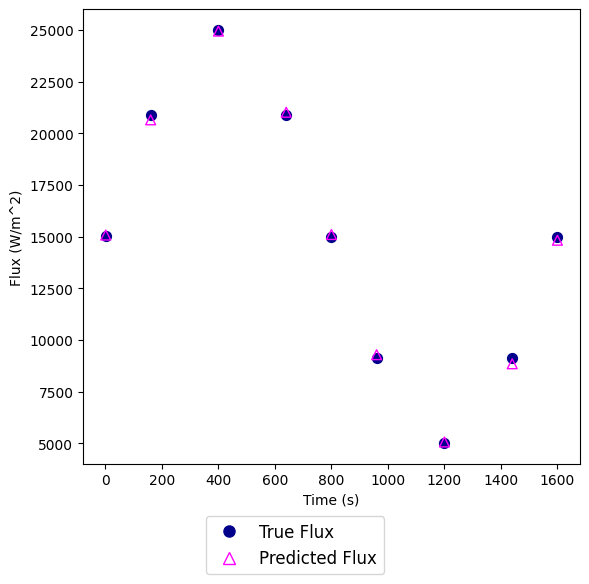

In [ ]:
fig,ax = plt.subplots(figsize=(6,6))

ax.scatter(temporal_points_sinusoidal,15000+ 10000 * np.sin(2*np.pi*temporal_points_sinusoidal/tmax),color='darkblue',marker='o',s=50)
ax.scatter(temporal_points_sinusoidal,np.array(q_vals)*Tmax,edgecolor='magenta',facecolor='None',marker='^',s=50)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Flux (W/m^2)')


circle = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='True Flux')

triangle = mlines.Line2D([], [], markeredgecolor='magenta',markerfacecolor='None', marker='^', linestyle='None',
                               markersize=8, label='Predicted Flux')

fig.legend(handles=[circle, triangle],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=1,
           fontsize=12)


plt.tight_layout(rect=[0,0.12,1,1])

plt.show()


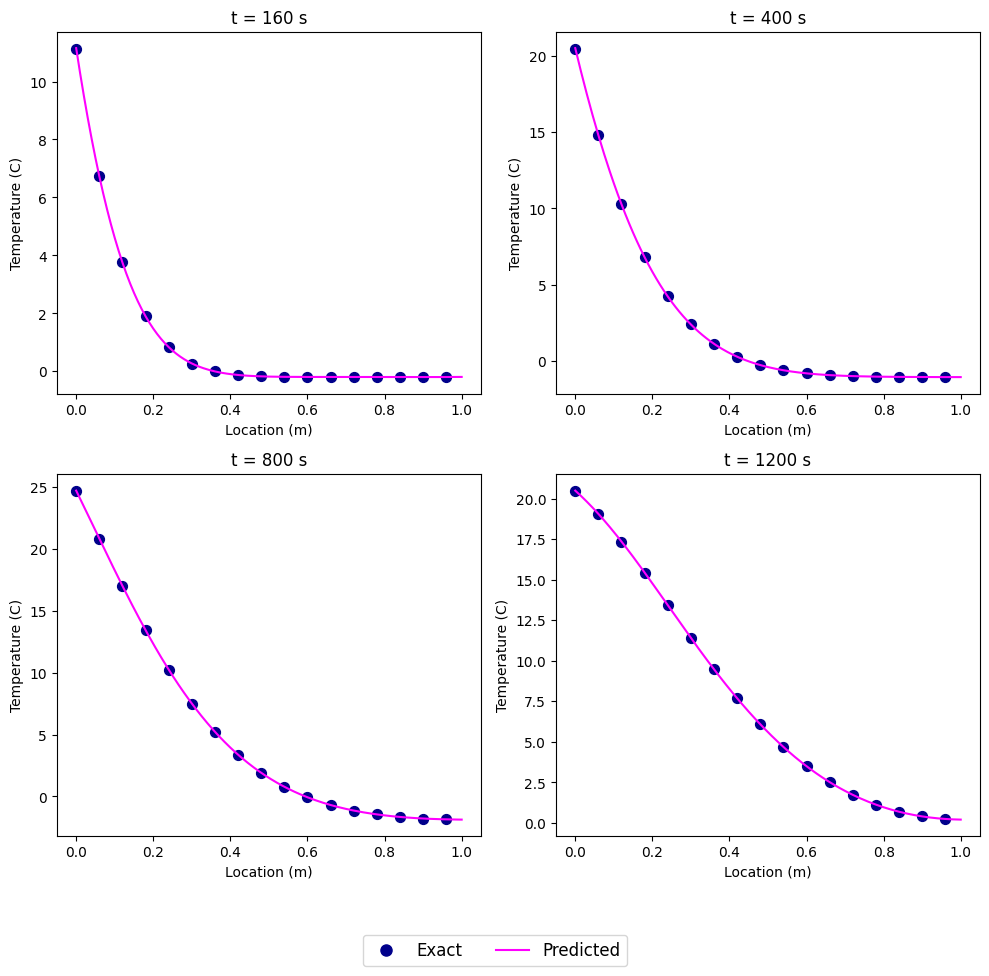

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))



axes[0, 0].plot(sinusoidal_x_np, sinusoidal_T_preds[0], color='magenta')
axes[0, 0].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal[int(160*1600/1600),0:-1:12],color='darkblue',marker='o',s=50)
axes[0, 0].set_title('t = 160 s')
axes[0, 0].set_xlabel('Location (m)')
axes[0, 0].set_ylabel('Temperature (C)')


axes[0, 1].plot(sinusoidal_x_np, sinusoidal_T_preds[1], color='magenta')
axes[0, 1].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal[int(400*1600/1600),0:-1:12],color='darkblue',marker='o',s=50)
axes[0, 1].set_title('t = 400 s')
axes[0, 1].set_xlabel('Location (m)')
axes[0, 1].set_ylabel('Temperature (C)')


axes[1, 0].plot(sinusoidal_x_np, sinusoidal_T_preds[2], color='magenta')
axes[1, 0].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal[int(800*1600/1600),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 0].set_title('t = 800 s')
axes[1, 0].set_xlabel('Location (m)')
axes[1, 0].set_ylabel('Temperature (C)')



axes[1, 1].plot(sinusoidal_x_np, sinusoidal_T_preds[3], color='magenta')
axes[1, 1].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal[int(1200*1600/1600),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 1].set_title('t = 1200 s')
axes[1, 1].set_xlabel('Location (m)')
axes[1, 1].set_ylabel('Temperature (C)')




line_symbol = mlines.Line2D([], [], color='magenta', label='Predicted')

scatter_symbol = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='Exact')

fig.legend(handles=[scatter_symbol,line_symbol],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=2,
           fontsize=12)


plt.tight_layout(rect=[0,0.1,1,1])

plt.show()

<br><br><br><br><br><br><br><br><br><br><br><br><br>

### Subcase 3.2: 10% Noisy Dataset

In [ ]:
tmax=1600
Tmax=25.11

In [ ]:
file = np.load('sinusoidal_pinn_data_noisy.npz')
sinusoidal_pinn_data_noisy = file['saved_data']
file.close()

In [ ]:
print(sinusoidal_pinn_data_noisy.shape)

(1809,)


In [ ]:
sinusoidal_pinn_data_noisy_tensor = torch.tensor(sinusoidal_pinn_data_noisy.tolist(),dtype=torch.float64)

print(sinusoidal_pinn_data_noisy_tensor.shape)

sinusoidal_x = sinusoidal_pinn_data_noisy_tensor[:,0:1]
sinusoidal_t = sinusoidal_pinn_data_noisy_tensor[:,1:2]/tmax
sinusoidal_T_noisy = sinusoidal_pinn_data_noisy_tensor[:,2:3]/Tmax

sinusoidal_x = sinusoidal_x.requires_grad_(True).to(device)
sinusoidal_t = sinusoidal_t.requires_grad_(True).to(device)
sinusoidal_T_noisy = sinusoidal_T_noisy.requires_grad_(True).to(device)

print(sinusoidal_x)
print(sinusoidal_t)
print(sinusoidal_T)


torch.Size([1809, 3])
tensor([[0.0000],
        [0.0050],
        [0.0100],
        ...,
        [0.9900],
        [0.9950],
        [1.0000]], dtype=torch.float64, requires_grad=True)
tensor([[6.2500e-04],
        [6.2500e-04],
        [6.2500e-04],
        ...,
        [1.0000e+00],
        [1.0000e+00],
        [1.0000e+00]], dtype=torch.float64, requires_grad=True)
tensor([[0.0575],
        [0.0197],
        [0.0240],
        ...,
        [0.1162],
        [0.1056],
        [0.1108]], dtype=torch.float64, requires_grad=True)


In [ ]:
# x_col = sinusoidal_x
# t_col = sinusoidal_t

In [ ]:
temporal_points_sinusoidal = np.array([1,160,400,640,800,960,1200,1440,1600]) # should be 900 instead of 960 it seems

print(temporal_points_sinusoidal)

[   1  160  400  640  800  960 1200 1440 1600]


In [ ]:
import gc
gc.collect()

2551

In [ ]:
def penalty_scheduler(epoch, lambda_data, lambda_bc, change_epoch) :
  if epoch < change_epoch :
    return lambda_data, lambda_bc*0
  else :
    return lambda_data, lambda_bc

In [ ]:
models_noisy = []
q_vals_noisy = []

for i,p in zip(range(len(temporal_points_sinusoidal)),temporal_points_sinusoidal):

    print(f"Training for temporal point t = {p} s ...\n")

    model = PINN_Architecture(num_hidden_layers=3, neurons_per_layer=30,SiLU_Activation=True).to(device)
    model = model.to(torch.float64)

    lr_nn = 0.001
    # lr_alpha = 0.001
    lr_q = 6.5 # 6.5 goated



    # alpha = nn.Parameter(torch.tensor([0.001*3600],device=device, requires_grad=True))
    q = nn.Parameter(torch.tensor([0.0],device=device, requires_grad=True))

    opt_nn = torch.optim.Adam(model.parameters(), lr=lr_nn)
    # opt_alpha = torch.optim.Adam([alpha], lr=lr_alpha)
    opt_q = torch.optim.Adam([q], lr=lr_q)

    sched_nn_1 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=1.0)
    sched_nn_2 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=0.0,total_iters=10_000)
    sched_nn_3 = torch.optim.lr_scheduler.ConstantLR(opt_nn, factor=0.05,total_iters=30_000)

    sched_nn = torch.optim.lr_scheduler.SequentialLR(opt_nn,
                                                     schedulers = [sched_nn_1,
                                                                   sched_nn_2,
                                                                   sched_nn_3
                                                                   ],
                                                     milestones=[20_000,30_000]
    )

    # sched_alpha = torch.optim.lr_scheduler.ExponentialLR(opt_alpha, gamma=1.0)

    #sched_q = torch.optim.lr_scheduler.LinearLR(opt_q, start_factor=0.02, end_factor=1.0, total_iters=2000)
    sched_q_1 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=1)
    sched_q_2 = torch.optim.lr_scheduler.ConstantLR(opt_q, factor=0.8,total_iters=20_000)
    sched_q = torch.optim.lr_scheduler.SequentialLR(opt_q,
                                                    schedulers=[sched_q_1,
                                                                sched_q_2
                                                                ],
                                                    milestones=[40_000]
    )

    all_trainable_params = list(model.parameters()) + [q]

    k = 237

    print(f"Confirming that t = {sinusoidal_t[i*201,0]*tmax} s")

    l_data = 1000
    l_bc = 1
    start=0


    train(model,
        opt_nn,opt_q,None,sched_nn,sched_q,None,
        sinusoidal_x[i*201:i*201+200],sinusoidal_t[i*201:i*201+200],sinusoidal_T_noisy[i*201:i*201+200],
        None,q,k,
        lambda_data=l_data,lambda_pde=0,lambda_bc=l_bc,
        start_epoch=start,epochs=60_000,include_gov_eq_loss=False,tmax=tmax,Tmax=Tmax,save_freq=None,
        penalty_scheduler=penalty_scheduler,change_args=(20_000,))





    # lbfgs_iter = 0
    # lbfgs_optimization(model,
    #                linear_x[i*201:i*201+200],linear_t[i*201:i*201+200],linear_T[i*201:i*201+200],x_col[i*201:i*201+200],t_col[i*201:i*201+200],
    #                None,q,k,
    #                lambda_data=10,lambda_pde=0,lambda_bc=1,
    #                lr=0.01,max_iter=1_000,max_eval=1_000,
    #                include_gov_eq_loss=False,tmax=2000)

    models_noisy.append(model)
    q_vals_noisy.append(q.item())




Training for temporal point t = 1 s ...

Confirming that t = 1.0 s
Epoch : 1 | Total loss : 4.252367535905914 | q : 0.0 | 
data loss : 0.004252367535905914 | bc loss : 1.9252455372889176e-06

Epoch : 1000 | Total loss : 0.2430017431284734 | q : 0.0 | 
data loss : 0.0002430017431284734 | bc loss : 7.673754053286675e-07

Epoch : 2000 | Total loss : 0.24293383575063832 | q : 0.0 | 
data loss : 0.00024293383575063832 | bc loss : 5.50177822541252e-06

Epoch : 3000 | Total loss : 0.24286518305898674 | q : 0.0 | 
data loss : 0.00024286518305898674 | bc loss : 2.6928595048595854e-05

Epoch : 4000 | Total loss : 0.24284903740759325 | q : 0.0 | 
data loss : 0.00024284903740759325 | bc loss : 3.531041563900481e-05

Epoch : 5000 | Total loss : 0.24282475139212056 | q : 0.0 | 
data loss : 0.00024282475139212055 | bc loss : 3.528628283496713e-05

Epoch : 6000 | Total loss : 0.2427772842164388 | q : 0.0 | 
data loss : 0.0002427772842164388 | bc loss : 2.88920124634904e-05

Epoch : 7000 | Total loss :

In [ ]:
sinusoidal_x_np = np.linspace(0,1,201,endpoint=True)

sinusoidal_x_pred = torch.from_numpy(sinusoidal_x_np).double()


test_inputs = []

for p in temporal_points_sinusoidal/tmax :
  sinusoidal_t_point = torch.from_numpy(np.array([p])).double()
  test_inputs.append(torch.cartesian_prod(sinusoidal_t_point,sinusoidal_x_pred)[:,[1,0]])



In [ ]:
sinusoidal_T_preds_noisy = []

for i in [2,3,5,7] : # 2nd,3td, 5th, 7th element
  sinusoidal_T_preds_noisy.append(models_noisy[i-1](test_inputs[i-1]).detach().numpy())

sinusoidal_T_preds_noisy = np.array(sinusoidal_T_preds_noisy).reshape(4,201)*Tmax

In [ ]:
file = np.load('sinusoidal_gt.npz')
T_gt_sinusoidal = file['saved_data']
file.close()

In [ ]:
file = np.load('sinusoidal_gt_noisy.npz')
T_gt_sinusoidal_noisy = file['saved_data']
file.close()

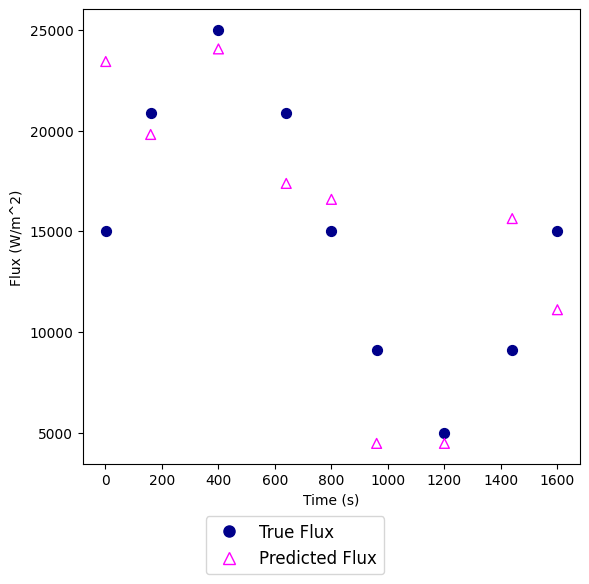

In [ ]:
fig,ax = plt.subplots(figsize=(6,6))

ax.scatter(temporal_points_sinusoidal,15000+ 10000 * np.sin(2*np.pi*temporal_points_sinusoidal/1600),color='darkblue',marker='o',s=50)
ax.scatter(temporal_points_sinusoidal,np.array(q_vals_noisy)*Tmax,edgecolor='magenta',facecolor='None',marker='^',s=50)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Flux (W/m^2)')


circle = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='True Flux')

triangle = mlines.Line2D([], [], markeredgecolor='magenta',markerfacecolor='None', marker='^', linestyle='None',
                               markersize=8, label='Predicted Flux')

fig.legend(handles=[circle, triangle],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=1,
           fontsize=12)


plt.tight_layout(rect=[0,0.12,1,1])

plt.show()


In [ ]:
print(np.array(sinusoidal_T_preds_noisy).shape)

(4, 201)


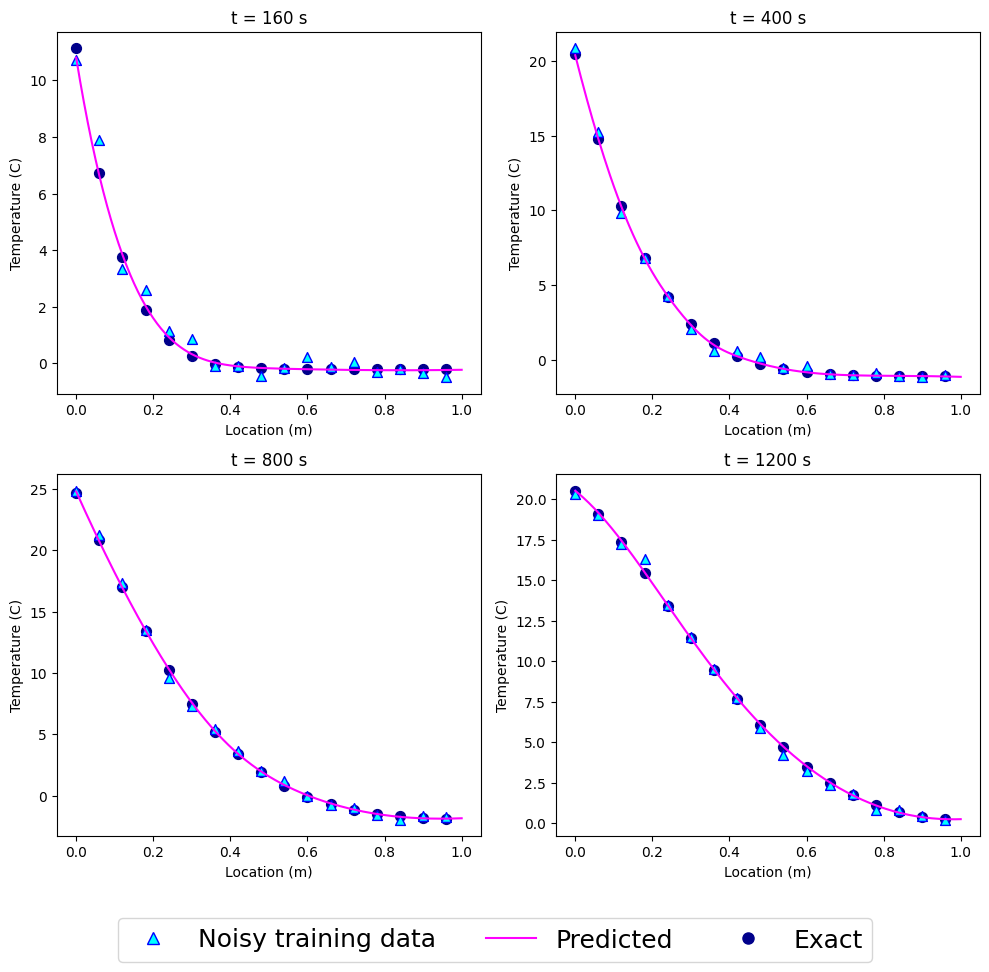

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))



axes[0, 0].plot(sinusoidal_x_np, sinusoidal_T_preds_noisy[0], color='magenta')
axes[0, 0].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal[int(160*1600/1600),0:-1:12],color='darkblue',marker='o',s=50)
axes[0, 0].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal_noisy[int(160*1600/1600),0:-1:12],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[0, 0].set_title('t = 160 s')
axes[0, 0].set_xlabel('Location (m)')
axes[0, 0].set_ylabel('Temperature (C)')


axes[0, 1].plot(sinusoidal_x_np, sinusoidal_T_preds_noisy[1], color='magenta')
axes[0, 1].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal[int(400*1600/1600),0:-1:12],color='darkblue',marker='o',s=50)
axes[0, 1].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal_noisy[int(400*1600/1600),0:-1:12],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[0, 1].set_title('t = 400 s')
axes[0, 1].set_xlabel('Location (m)')
axes[0, 1].set_ylabel('Temperature (C)')


axes[1, 0].plot(sinusoidal_x_np, sinusoidal_T_preds_noisy[2], color='magenta')
axes[1, 0].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal[int(800*1600/1600),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 0].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal_noisy[int(800*1600/1600),0:-1:12],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[1, 0].set_title('t = 800 s')
axes[1, 0].set_xlabel('Location (m)')
axes[1, 0].set_ylabel('Temperature (C)')



axes[1, 1].plot(sinusoidal_x_np, sinusoidal_T_preds_noisy[3], color='magenta')
axes[1, 1].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal[int(1200*1600/1600),0:-1:12],color='darkblue',marker='o',s=50)
axes[1, 1].scatter(sinusoidal_x_np[0:-1:12], T_gt_sinusoidal_noisy[int(1200*1600/1600),0:-1:12],marker='^',s=50,facecolor='cyan', edgecolor='blue', linewidth=1)
axes[1, 1].set_title('t = 1200 s')
axes[1, 1].set_xlabel('Location (m)')
axes[1, 1].set_ylabel('Temperature (C)')




line_symbol = mlines.Line2D([], [], color='magenta', label='Predicted')

circle = mlines.Line2D([], [], color='darkblue', marker='o', linestyle='None',
                               markersize=8, label='Exact')

triangle = mlines.Line2D([], [], marker='^', linestyle='None',
                               markersize=8, markerfacecolor='cyan', markeredgecolor='blue', linewidth=3, label='Noisy training data')

fig.legend(handles=[triangle,line_symbol,circle],
           loc='lower center',
           bbox_to_anchor=(0.5, 0.02),
           ncol=3,
           fontsize=18)


plt.tight_layout(rect=[0,0.1,1,1])

plt.show()